
As an emergent area of finance options on cryptocurrencies are relatively low volume but of growing interest to traders. Opinions differ on the properties of cryptocurrencies for simulation and hedging purposes. Some argue they act as currencies, some say they act as stores of value like gold, while others argue they act as commodities (inputs to other businesses). A few early studies in the literature have shown that options on Cryptocurrencies can be mispriced, and profit-making opportunities might exist.

# 1)
Pick a crypto currency (Bitcoin BTC, Ethereum ETH, Binance BNB, Solana SOL, or Ripple XRP) you will analyse. Use https://www.deribit.com/ to collect prices1 for put and call options for your selected cryptocurrency that are near the money (closest strike price to current price) for the different time periods (1 day to 4 Quarters) available.  Assume the Cryptocurrency follows a log‐normal model (geometric Brownian motion), i.e.,
$$
\frac{dS_t}{S_t} = \mu\,dt + \sigma\,dW_t
$$
where 𝑊𝑡 is a Wiener process, 𝜇 the constant drift, and 𝜎 > 0 is the diffusion coefficient.

### 1a) Download the options and historical prices to csv that you will use so that all analysis can be recreated.

We chose to analyse Bitcoin as it is the most talked about crypto currency

In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from datetime import datetime, timedelta
import time
from scipy.stats import norm
from scipy.optimize import brentq
import math


In [ ]:

# -------------------------------
# PART 1: Fetch BTC Option Data
# -------------------------------

# Get BTC options metadata
resp = requests.get("https://www.deribit.com/api/v2/public/get_instruments",
                    params={"currency": "BTC", "kind": "option", "expired": "false"})
resp.raise_for_status()
option_meta = pd.DataFrame(resp.json()["result"])

# Select relevant columns
option_meta = option_meta[["instrument_name", "strike", "expiration_timestamp", "option_type"]]

# Convert to datetime
option_meta["expiry"] = pd.to_datetime(option_meta["expiration_timestamp"], unit="ms")
option_meta["days2exp"] = (option_meta["expiry"] - pd.Timestamp.today()).dt.days

# Get latest quote info for each instrument
quotes = []
for name in option_meta["instrument_name"]:
    try:
        book = requests.get("https://www.deribit.com/api/v2/public/get_book_summary_by_instrument",
                            params={"instrument_name": name}).json()["result"][0]
        quotes.append({
            "instrument_name": name,
            "bid": book.get("bid_price"),
            "ask": book.get("ask_price"),
            "spot": book.get("underlying_price"),
            "market_price": book.get("mark_price"),
            "iv": book.get("mark_iv")
        })
    except Exception as e:
        continue  # skip instruments with missing data

# Convert to DataFrame and merge
quotes_df = pd.DataFrame(quotes)
options = option_meta.merge(quotes_df, on="instrument_name")

# Filter for 1 to 365 days to expiry
options = options[(options.days2exp >= 1) & (options.days2exp <= 365)].copy()

# Save to CSV
options.to_csv("BTC_options_clean.csv", index=False)

# Optional: average spot price
btc_price = options['spot'].mean()
print("BTC Option data saved to BTC_options_clean.csv")
print(f"Approx. spot price: ${btc_price:,.2f}")

BTC Option data saved to BTC_options_clean.csv
Approx. spot price: $88,646.81


In [3]:
#import btc_options_clean
options = pd.read_csv('BTC_options_clean.csv')
options.head()

,instrument_name,strike,expiration_timestamp,option_type,expiry,days2exp,bid,ask,spot,market_price,iv
0,BTC-23APR25-76000-C,76000.0,1745395200000,call,2025-04-23 08:00:00,1,0.0980,0.1600,87268.887090,0.129161,80.36
1,BTC-23APR25-76000-P,76000.0,1745395200000,put,2025-04-23 08:00:00,1,NaN,0.0001,87268.887090,0.000033,80.36
2,BTC-23APR25-78000-C,78000.0,1745395200000,call,2025-04-23 08:00:00,1,0.0740,0.1375,87268.887090,0.106267,70.23
3,BTC-23APR25-78000-P,78000.0,1745395200000,put,2025-04-23 08:00:00,1,NaN,0.0001,87268.887090,0.000056,70.23
4,BTC-23APR25-80000-C,80000.0,1745395200000,call,2025-04-23 08:00:00,1,0.0505,0.1160,87269.346062,0.083429,61.83


BTC option prices successfully downloaded and stored in `BTC_options_clean.csv`.

## 1b) Estimate volatility using different historical time series of varying lengths.

Volatility was estimated using historical daily returns from BTC spot prices. The varying lengths were choosen based on the time to expiry available for the BTC options in order to have comparable volatility lenghts later on.

In [ ]:

# -------------------------------
# PART 2: Fetch BTC Historical Prices
# -------------------------------

# Define time range: last 365 days
end_ts = int(time.time() * 1000)
start_ts = end_ts - 10 * 365 * 24 * 3600 * 1000

# Pull historical spot prices from Deribit
resp = requests.get(
    "https://www.deribit.com/api/v2/public/get_tradingview_chart_data",
    params={
        "instrument_name": "BTC-PERPETUAL",
        "resolution": "1D",
        "start_timestamp": start_ts,
        "end_timestamp": end_ts
    }
)
resp.raise_for_status()

# Clean and format data
hist_data = pd.DataFrame(resp.json()["result"])
hist_data["datetime"] = pd.to_datetime(hist_data["ticks"], unit="ms")
hist_data.set_index("datetime", inplace=True)

# Save to CSV
hist_data.to_csv("BTC_historical_prices.csv")
print("BTC historical price data saved to BTC_historical_prices.csv")

# Optional preview
hist_data[["open", "close"]].tail()

BTC historical price data saved to BTC_historical_prices.csv


,open,close
datetime,,
2025-04-17 08:00:00,84699.5,84656.0
2025-04-18 08:00:00,84656.5,85231.5
2025-04-19 08:00:00,85231.5,84796.5
2025-04-20 08:00:00,84796.5,87454.5
2025-04-21 08:00:00,87454.5,87337.0


In [ ]:
# --- Calculate daily log returns ---
S=hist_data['close']
ln_r = np.log(S / S.shift(1)).dropna()  # Drop NaN resulting from shift

rolling_volatility = {}
for days in sorted(options['days2exp'].unique()):
    # Rolling standard deviation of log returns, annualized
    rolling_volatility[days] = ln_r.rolling(window=days).std() * np.sqrt(365)

# --- Create a DataFrame from the rolling volatility dictionary ---
volatility_df = pd.DataFrame(rolling_volatility, index=ln_r.index)

# Filter for the last year
last_date = volatility_df.index.max()
one_year_ago = last_date - pd.DateOffset(years=1)
volatility_last_year = volatility_df[volatility_df.index >= one_year_ago]

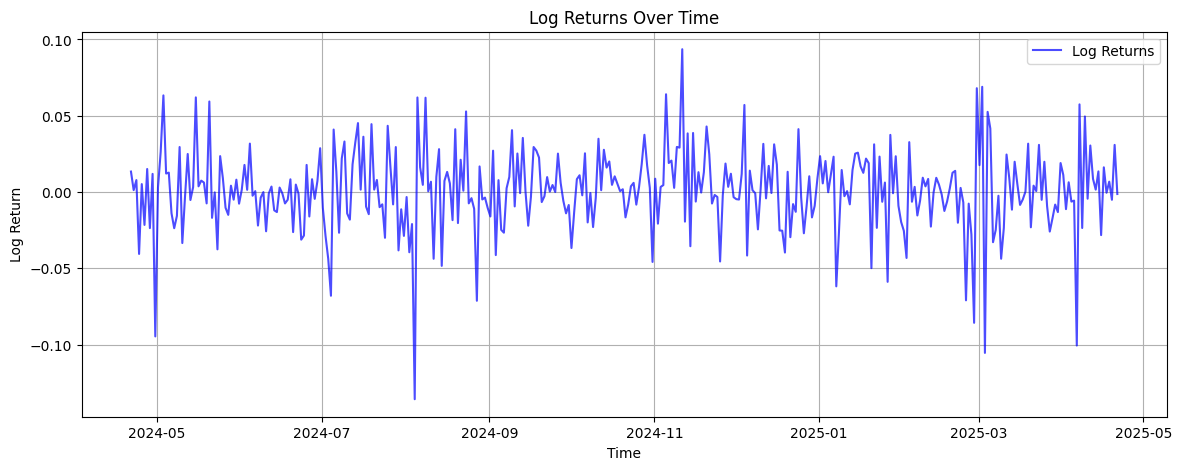

In [ ]:
# --- Plot the log returns ---
plt.figure(figsize=(14, 5))
plt.plot(ln_r[ln_r.index >= one_year_ago], label='Log Returns', color='blue', alpha=0.7)
plt.title('Log Returns Over Time')
plt.xlabel('Time')
plt.ylabel('Log Return')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

We can see that Bitcoin is quite volatily asset, especially in periods of greater losses.

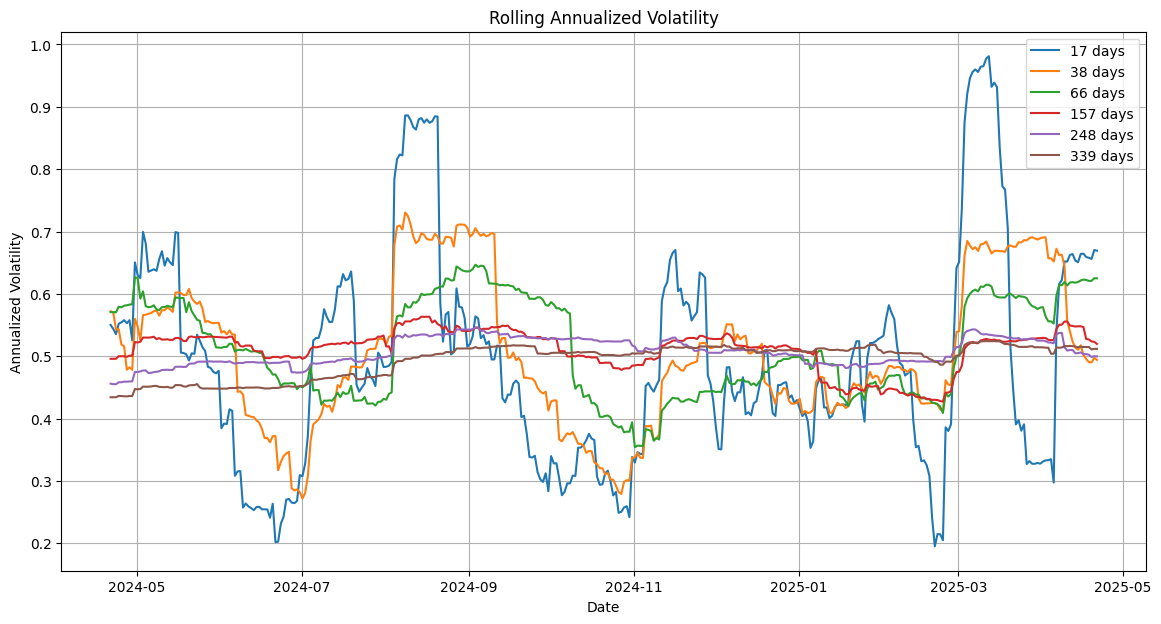

In [ ]:
# --- Plot the rolling volatility ---
plt.figure(figsize=(14, 7))
for days in sorted(options['days2exp'].unique()):
  if days >10:
    plt.plot(volatility_last_year[days], label=f'{days} days')

plt.title('Rolling Annualized Volatility')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

As expected, the volatility over smaller periods is higher than for longer time frames. In the case of Bitcoin, there was a time where the shorter term volatility was almost 100%.

For bigger period lengths the volatility stabilizes around 50%, which is an overall high volatility in itself, compared to VIX, that rounds 20% of volatility for the market based on SP500.

## 1c) Calculate the implied volatility for different option lengths and compare to the historical volatility. What does this tell you?

The implied volatility is given by the option prices observed in the market.

Based on the Black Scholes Merton formula for option pricing:

For a call option:
$$
C = S_0 N(d_1) - K e^{-rT} N(d_2)
$$

For a put option:
$$
P = K e^{-rT} N(-d_2) - S_0 N(-d_1)
$$

where:
$$
d_1 = \frac{\ln(S_0 / K) + (r + 0.5 \sigma^2) T}{\sigma \sqrt{T}}
$$
$$
d_2 = d_1 - \sigma \sqrt{T}
$$

In these formulas:
- ${ S_0 }$ is the current stock price.
- ${ K }$ is the strike price.
- ${ T }$ is the time to maturity.
- ${ r }$ is the risk-free interest rate.
- ${ \sigma }$ is the volatility of the underlying stock.
- ${ N(\cdot) }$ is the cumulative distribution function of the standard normal distribution.

It is not posible to invert the equation to analitically determin the volatility, therefore we will use and iterative search procedure to find s.

This procedure will "try" different values for the for the volatilty and input that into the BSM option pricing formula iteratively. Next, using **brentq**, it will find the value that minimizes the price difference between the extracted market option price and the option price given by the BSM formula.

In [ ]:
calculated_iv=options.copy()

def bs_price(S, K, T, sigma, option_type='call', r=0.04):
    if T == 0 or sigma == 0:
        return max(0, S - K) if option_type == 'call' else max(0, K - S)

    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)

    if option_type == 'call':
        return S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        return K * math.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Compute implied volatility per row
def compute_iv(row):
    S = row['spot']
    K = row['strike']
    T = row['days2exp'] / 365
    option_type = row['option_type']
    r = 0.04

    try:
        option_price = row['market_price'] * S  # Convert to USD

        # Objective function for solver
        def objective(sigma):
            return bs_price(S, K, T, sigma, option_type, r) - option_price
        iv = brentq(objective, 1e-6, 5)
        return iv
    except:
        return np.nan  # Return NaN if IV can't be calculated

# Apply to your DataFrame
calculated_iv['calculated_iv'] = calculated_iv.apply(compute_iv, axis=1)*100


In [ ]:
calculated_iv.head()

,instrument_name,strike,expiration_timestamp,option_type,expiry,days2exp,bid,ask,spot,market_price,iv,ask_iv,bid_iv,calculated_iv
44,BTC-23APR25-76000-C,76000.0,1745395200000,call,2025-04-23 08:00:00,1,0.1000,0.1625,87497.911243,0.131499,80.59,None,None,NaN
45,BTC-23APR25-76000-P,76000.0,1745395200000,put,2025-04-23 08:00:00,1,NaN,0.0001,87497.853733,0.000071,80.59,None,None,103.076115
46,BTC-23APR25-78000-C,78000.0,1745395200000,call,2025-04-23 08:00:00,1,0.0765,0.1410,87500.005144,0.108746,70.74,None,None,86.641208
47,BTC-23APR25-78000-P,78000.0,1745395200000,put,2025-04-23 08:00:00,1,NaN,0.0002,87500.005144,0.000111,70.74,None,None,90.455044
48,BTC-23APR25-80000-C,80000.0,1745395200000,call,2025-04-23 08:00:00,1,0.0530,0.1185,87500.005144,0.085995,62.00,None,None,77.339271


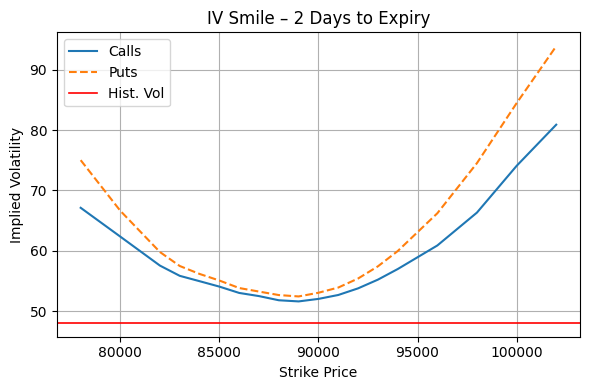

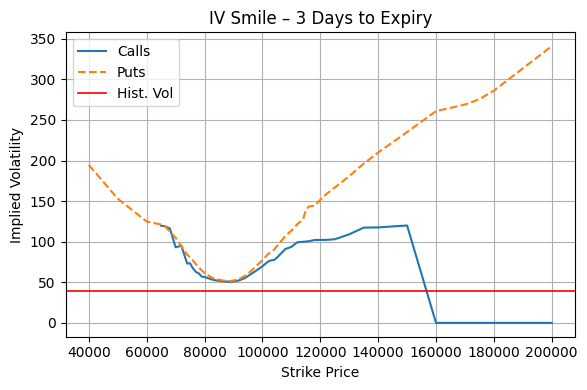

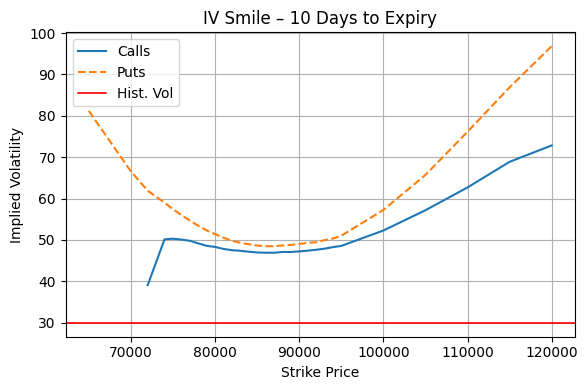

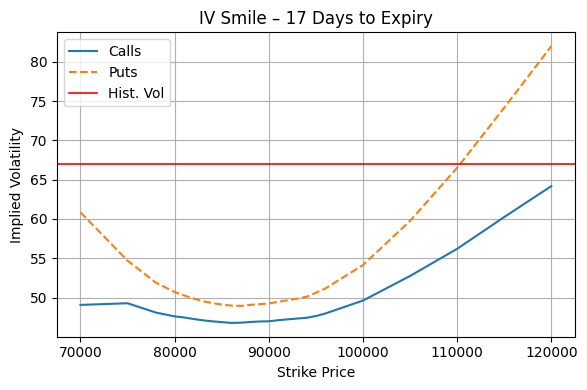

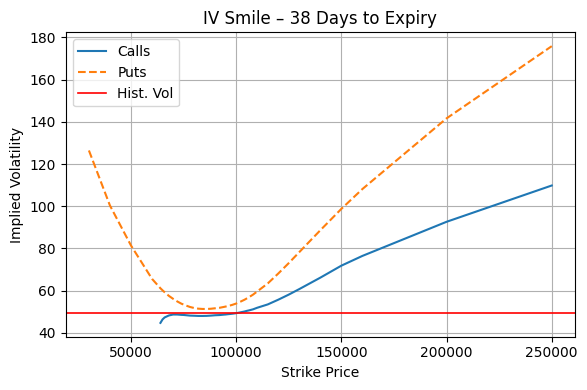

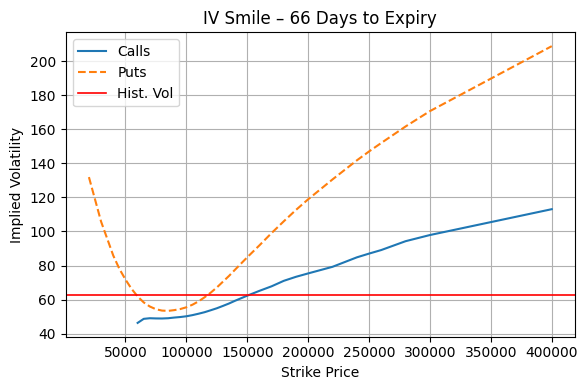

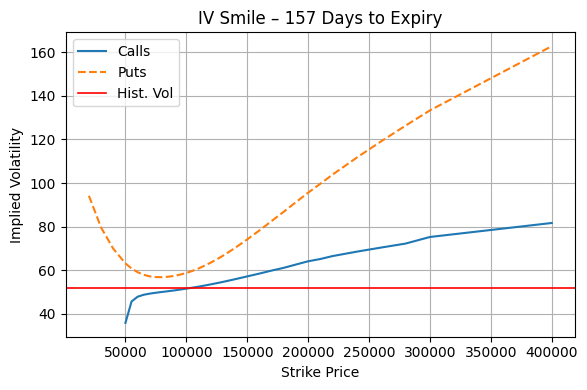

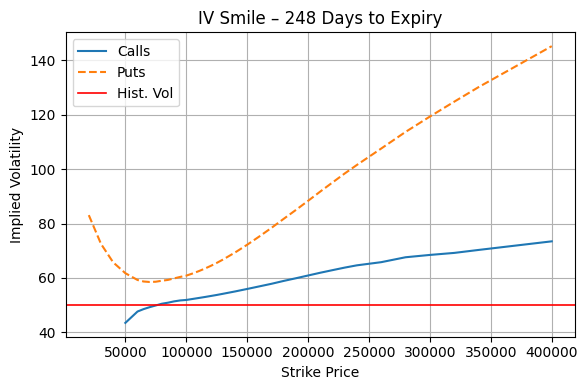

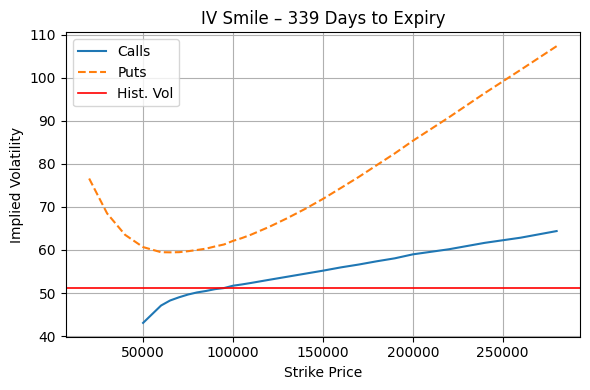

In [ ]:
historical_vol = volatility_last_year.iloc[-1]

for days in sorted(options['days2exp'].unique()):
    if days > 1:
        subset = calculated_iv[calculated_iv['days2exp'] == days]
        calls = subset[subset['option_type'] == 'call'].sort_values('strike')
        puts = subset[subset['option_type'] == 'put'].sort_values('strike')

        plt.figure(figsize=(6, 4))  # Smaller figure size for individual plots

        if not calls.empty:
            plt.plot(calls['strike'], calls['calculated_iv'], label='Calls', linestyle='solid')

        if not puts.empty:
            plt.plot(puts['strike'], puts['calculated_iv'], label='Puts', linestyle='dashed')

        # Add horizontal line for historical vol
        plt.axhline(historical_vol[days]*100, color='red', linestyle='solid', linewidth=1.2, label='Hist. Vol')

        plt.xlabel('Strike Price')
        plt.ylabel('Implied Volatility')
        plt.title(f'IV Smile – {days} Days to Expiry')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
        print("/n")

These plots compare implied volatility with historical volatility across diferent timeframes. Implied volatility is forward looking and often higher due to risk premium were historical volatilities are backward looking.
Since implied volatility is based on option prices, the high IV can indicate that traders are expecting big movements around the asset pricing.

- Implied volatility (IV) generally **lies above** historical volatility (HV) estimates which can be observed in the above graphs, except for the 17-day timeframe, were HV was higher.
- Where IV > HV, which is most cases, it can mean that the market is expecting more volatility than what has been realized meaning that **options might be overvalued**.
- In the 17-day timeframe, where HV > IV this can mean that the market is expecting lower volatility than what has been realized, which can mean **that options might be undervalued**, and that could be a good oportunity for traders.
- This suggests the **market is pricing in higher future uncertainty** than what has been observed in the past.
- This difference — the “risk premium” — is often seen in volatile assets like cryptocurrencies.


## 1d) Explore the market implied volatility (volatility surfaces) what do you find? What does it tell you about crypto currency?

In [ ]:
spot_price = hist_data['close'].iloc[-1]
expiry_dates = options['expiry'].unique()
formatted_dates = [pd.to_datetime(date).strftime('%Y-%m-%d') for date in expiry_dates]
expirations = formatted_dates

In [ ]:
last_date = hist_data.index.max()
one_year_ago = last_date - pd.DateOffset(years=1)
hist_data = hist_data[hist_data.index >= one_year_ago]

In [ ]:
def plot_volatility_surface_calc(option_type='call', max_days=365, moneyness_range=0.2):
  surface_data = []
  for date_str in expirations:
    try:
      expiration_days = (pd.to_datetime(date_str) - pd.Timestamp.today()).days
      if expiration_days > max_days or expiration_days <= 0:
        continue  # skip if beyond desired horizon or already expired

      opts = calculated_iv[calculated_iv['expiry'].dt.date == pd.to_datetime(date_str).date()]
      opts = opts[opts['option_type'] == option_type]
      df = opts.copy()
      df = df[df['calculated_iv'].notnull() & (df['calculated_iv'] > 0)]
      df['moneyness'] = df['strike'] / spot_price
      df = df[(df['moneyness'] >= 1 - moneyness_range) & (df['moneyness'] <= 1 + moneyness_range)]
      df['expiration'] = expiration_days

      surface_data.append(df[['moneyness', 'expiration', 'calculated_iv']])
    except Exception as e:
      print(f"Error fetching data for {date_str}: {e}")

  if not surface_data:
    print("No valid surface data available.")
    return

  surface_df = pd.concat(surface_data)


  # Pivot and interpolate
  grid = surface_df.pivot_table(index='expiration', columns='moneyness', values='calculated_iv')
  grid = grid.sort_index()
  grid = grid.interpolate(axis=0).interpolate(axis=1)

  X, Y = np.meshgrid(grid.columns, grid.index)
  Z = grid.values

  # Plot
  fig = plt.figure(figsize=(14, 8))
  ax = fig.add_subplot(111, projection='3d')
  surf = ax.plot_surface(X, Y, Z, cmap=cm.viridis, edgecolor='k', alpha=0.85)

  ax.set_title(f'BTC {option_type.capitalize()} Volatility Surface')
  ax.set_xlabel('Moneyness (Strike / Spot)')
  ax.set_ylabel('Time to Expiration (Days)')
  ax.set_zlabel('Implied Volatility')
  fig.colorbar(surf, shrink=0.5, aspect=10)
  plt.tight_layout()
  plt.show()


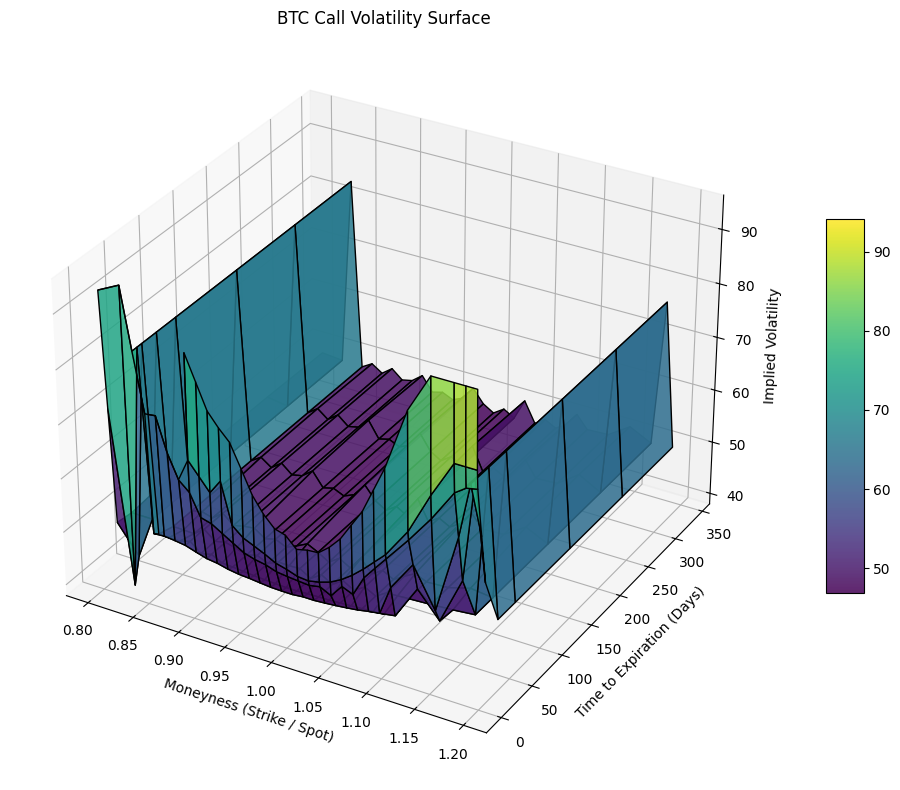

In [ ]:
plot_volatility_surface_calc(option_type='call')

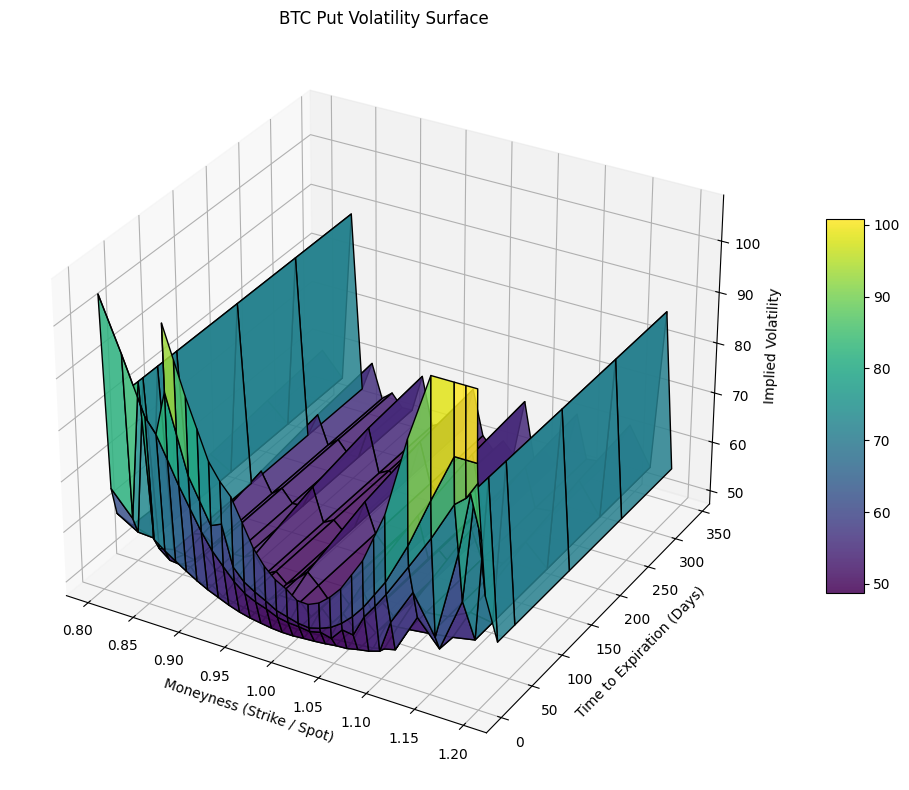

In [ ]:
plot_volatility_surface_calc(option_type='put')

**Volatility surfaces interpretation**

The volatility surface helps us to understand how the implied volatility changes across diferent strike prices and diferent times to expiration. This represents the expectations of the markets regarding the volatility of the price of Bitcoin. This representations allows to visualize volatility smiles and skweness across these two variables.

**Volatility smiles considerations**:
- Implied volatility tends to stabilize in longer times to expiration since they are less influenced by short-time changes in the price of Bitcoin. The smile flattens.
- The further away the strike price is from the spot, the higher the volatility, both in calls and puts. This accentuated smile pattern which we can see across diferent times to expiry, indicates that the market expects extreme moves in the price of Bitcoin.
- Overall put options tend to be more volatile due to a crash fear, and investors want to be protected.

**Volatility smirks considerations**:
- In closer times to expiration, we observe a smirk to the left which, implies a greater probability of large underlying price falls;
- In a medium time to expiration (around 66 day), the smirk is reversed to the right, implying that the market is expecting extreme movements around increases in the price;
- Put options demonstrate more skweness given the higher interest in protecting the downside risk.

**Time to expiration considerations:**
- In shorter periods to expiration the volatility is higher due to this type of assets having higher uncertainty around the pricing, which causes investors to require a higher risk premium for near term protection.


**What This Tells Us About Crypto**:
- This behavior is consistent with **non-constant volatility** models — the Black-Scholes assumptions are clearly violated.
- Crypto markets tend to exhibit **asymmetric risk, heavy tails, and demand for protection** — especially in OTM options.
- The surface reinforces the idea that BTC behaves more like a **speculative asset or commodity**, not a traditional currency.

In [ ]:
def plot_otm_option_iv(expirations=expirations):
    expirations = expirations

    call_ivs = []
    put_ivs = []
    expiration_dates = []
    spot_price = hist_data['close'].iloc[-1]

    for date in expirations:
        try:
            opts = calculated_iv[calculated_iv['expiry'].dt.date == pd.to_datetime(date).date()]
            calls = opts[opts['option_type'] == 'call']
            puts = opts[opts['option_type'] == 'put']

            # Find next higher strike for call (slightly OTM)
            call_strikes = calls['strike']
            call_strike_otm = call_strikes[call_strikes > spot_price * 1.05].min()

            # Find next lower strike for put (slightly OTM)
            put_strikes = puts['strike']
            put_strike_otm = put_strikes[put_strikes < spot_price * 0.95].max()

            # Extract call IV
            call_iv = None
            if not pd.isna(call_strike_otm):
                call_row = calls[calls['strike'] == call_strike_otm]
                if not call_row.empty:
                    iv = call_row['calculated_iv'].iloc[0]
                    if pd.notnull(iv) and iv > 0.001:
                        call_iv = iv

            # Extract put IV
            put_iv = None
            if not pd.isna(put_strike_otm):
                put_row = puts[puts['strike'] == put_strike_otm]
                if not put_row.empty:
                    iv = put_row['calculated_iv'].iloc[0]
                    if pd.notnull(iv) and iv > 0.001:
                        put_iv = iv

            # Append if valid
            if call_iv is not None or put_iv is not None:
                expiration_dates.append(date)
                call_ivs.append(call_iv)
                put_ivs.append(put_iv)

        except Exception as e:
            print(f"Error processing {date}: {e}")

    # Plot
    plt.figure(figsize=(14, 7))
    if any(call_ivs):
        plt.plot(expiration_dates, call_ivs, marker='o', linestyle='-', color='blue', label='Call IV (OTM)')
    if any(put_ivs):
        plt.plot(expiration_dates, put_ivs, marker='o', linestyle='-', color='red', label='Put IV (OTM)')

    plt.title(f'Slightly OTM Implied Volatility Across Expirations for BTC')
    plt.xlabel('Expiration Date')
    plt.ylabel('Implied Volatility')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


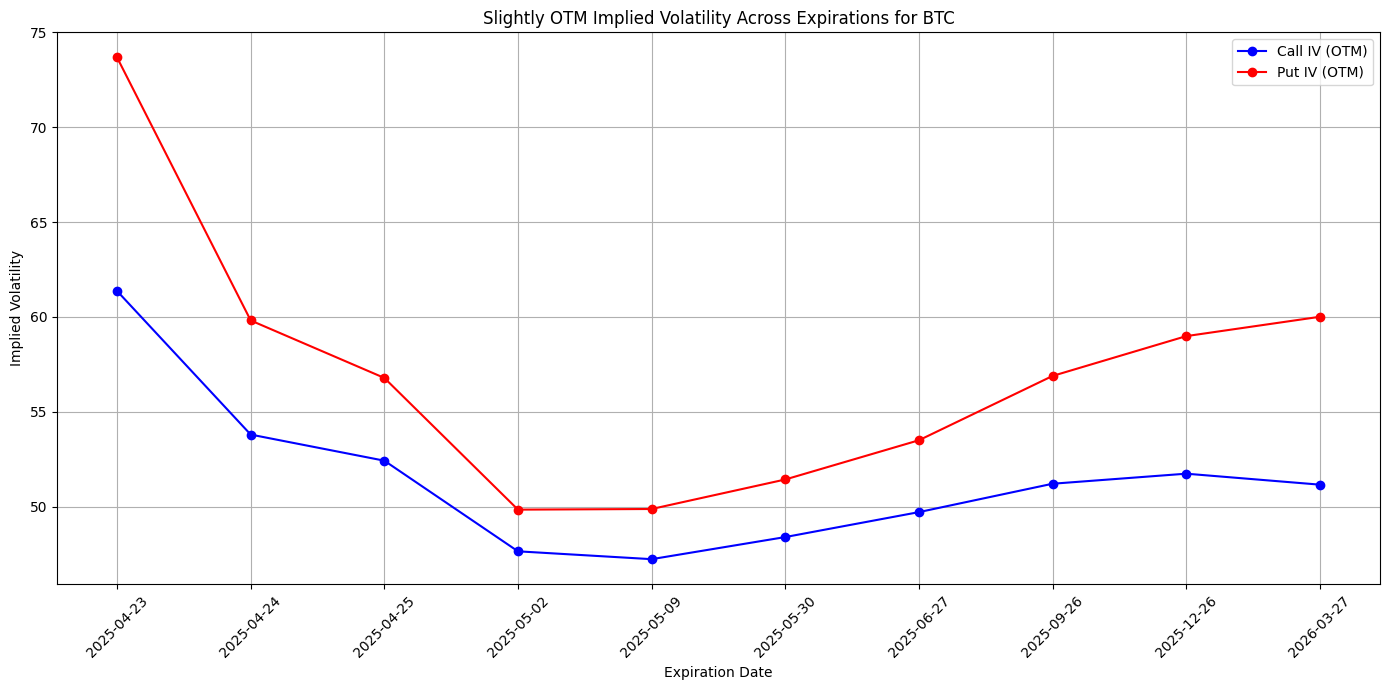

In [ ]:
plot_otm_option_iv()

This plot further consolidates that:
- Put options have higher volatility than call options, which does not support the Put-Call Parity theory.
- Options closer to maturity have higher volatility given the uncertainty around the pricing of crypto.

## 1e) How would you use the available options to achieve the following, calculate exactly what you would buy and plot the expected payoff of the entire portfolio:
### 1e)i) Insure against downside risk on an existing portfolio of the underlying with a value of €10 million but retain upside exposure.

Given that we have a long position on BTC, to propect against downside risk we must **purchase a put option to limit the possible losses** given by a decrease in the price of the asset.

The option will have a medium expiry date (aproximatly 6 months), even tough it is more expensive than lower time to expiration options, it needs less renewals.
The option will also be slighty OTM, 15% below market, to manage costs.

In [ ]:
options['market_price_usd']=options['market_price']*options['spot']

In [ ]:
put_opts = options[options['option_type'] == 'put']
put_opts = put_opts[np.abs(put_opts['strike'] - btc_price) < btc_price*0.15]
put_opts = put_opts[put_opts['days2exp']==157]
put_opts

,instrument_name,strike,expiration_timestamp,option_type,expiry,days2exp,bid,ask,spot,market_price,iv,market_price_usd
515,BTC-26SEP25-80000-P,80000.0,1758873600000,put,2025-09-26 08:00:00,157,0.0850,0.0865,89600.03,0.085621,53.72,7671.671945
517,BTC-26SEP25-85000-P,85000.0,1758873600000,put,2025-09-26 08:00:00,157,0.1110,0.1125,89597.61,0.111664,53.49,10004.865154
519,BTC-26SEP25-90000-P,90000.0,1758873600000,put,2025-09-26 08:00:00,157,0.1405,0.1430,89599.26,0.141894,53.47,12713.620694
521,BTC-26SEP25-95000-P,95000.0,1758873600000,put,2025-09-26 08:00:00,157,0.1750,0.1775,89597.73,0.175788,53.52,15750.183362
523,BTC-26SEP25-100000-P,100000.0,1758873600000,put,2025-09-26 08:00:00,157,0.2120,0.2675,89602.64,0.213193,53.71,19102.610828


Since we want to protect the downside exposure, we will select the option with strike price of 85 000USD, this is the put option BTC-26SEP25-85000-P.

Buying 113 put contracts at strike $85000.0, costing $10004.87 each
Buying 113 put contracts at strike $85000.0, expiring in 157 days
Total premium paid for hedge: $1,128,620.95
Each put costs: $10004.87


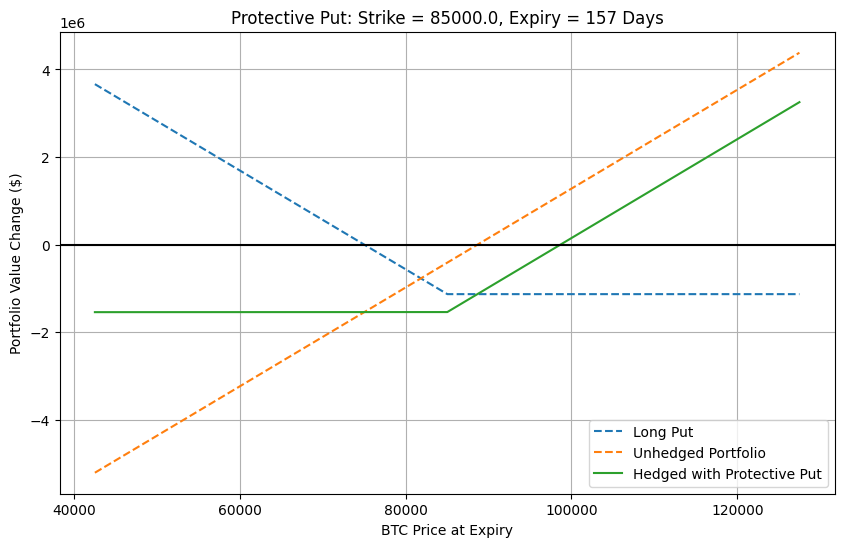

In [ ]:
# Assume €10M exposure to BTC
portfolio_value = 10_000_000
btc_units = portfolio_value / btc_price

# Choose a put option
put_option = options[(options['instrument_name'] == 'BTC-26SEP25-85000-P')]

put_strike = put_option['strike'].values[0]
put_price = put_option['market_price_usd'].values[0]
put_days = put_option['days2exp'].values[0]

# Number of contracts needed (1 BTC per contract)
contracts = btc_units

# Price range for simulation
S_range = np.linspace(put_strike * 0.5, put_strike * 1.5, 20000)
put_graph = np.maximum(put_strike*contracts - S_range*contracts, 0) - put_price*contracts
put_payoff = np.maximum(put_strike - S_range, 0) - put_price
portfolio_change = btc_units * (S_range - btc_price)
hedged_portfolio = portfolio_change + contracts * put_payoff

# Show what you're buying
print(f"Buying {contracts:.0f} put contracts at strike ${put_strike}, costing ${put_price:.2f} each")
print(f"Buying {contracts:.0f} put contracts at strike ${put_strike}, expiring in {put_days} days")
# Total premium cost
total_cost = contracts * put_price
print(f"Total premium paid for hedge: ${total_cost:,.2f}")
# Optional: show what we're buying
print(f"Each put costs: ${put_price:.2f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(S_range, put_graph, label="Long Put",linestyle='--')
plt.plot(S_range, portfolio_change, label="Unhedged Portfolio",linestyle='--')
plt.plot(S_range, hedged_portfolio, label="Hedged with Protective Put")
plt.axhline(0, color='black')
plt.xlabel("BTC Price at Expiry")
plt.ylabel("Portfolio Value Change ($)")
plt.title(f"Protective Put: Strike = {put_strike}, Expiry = {put_days} Days")
plt.legend()
plt.grid(True)
plt.show()

We implemented a **protective put** strategy to hedge a €10 million BTC portfolio.

**Key Takeaways**:
- The hedged portfolio flattens below the strike: **losses are capped**.
- Upside remains **unlimited**.
- This comes at a cost: the **premium paid for the puts**, which acts like insurance.

### 1e)ii) Achieve the above insurance against downside risk in a cheaper manner by giving up upside exposure.

To reduce the cost of the strategy, we can sacrifice upside exposure and **apply a bull put spread**. This means that we must **sell a put option with a higher strike price**, and the **profit** from that sell will go towards the **purchase of the put option with lower price**.

The choosen put option for shorting we will select is the option with strike price of 95 000USD, this is the put option BTC-26SEP25-95000-P.

Buying 113 puts at $85000.0, cost: $10004.87
Selling 113 puts at $95000.0, premium: $15750.18
Net cost per spread: $-5745.32
Total cost of put spread hedge: $-648,113.33


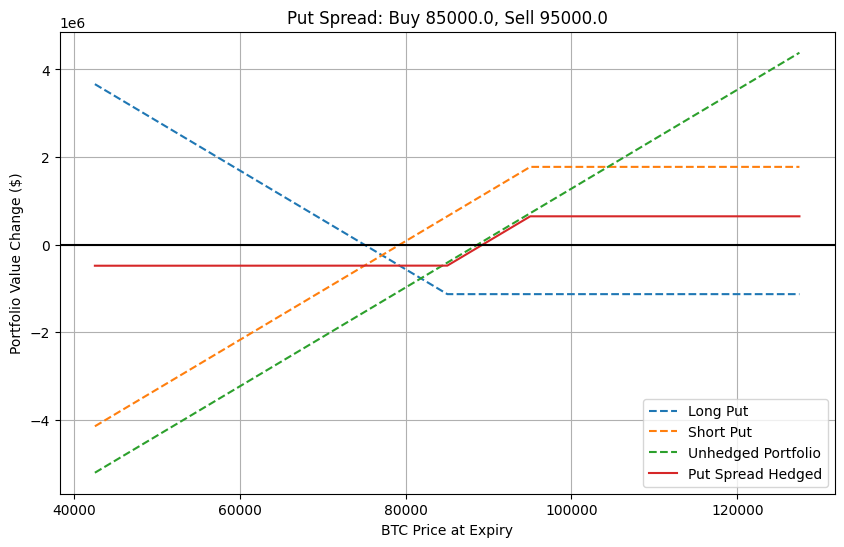

In [ ]:
# Choose a put option
sh_put_option = options[(options['instrument_name'] == 'BTC-26SEP25-95000-P')]

sh_put_strike = sh_put_option['strike'].values[0]
sh_put_price = sh_put_option['market_price_usd'].values[0]
sh_put_days = sh_put_option['days2exp'].values[0]

# Price range for simulation
S_range = np.linspace(put_strike * 0.5, put_strike * 1.5, 20000)
put_graph = np.maximum(put_strike*contracts - S_range*contracts, 0) - put_price*contracts
sh_put_graph = sh_put_price * contracts - np.maximum(sh_put_strike * contracts - S_range * contracts, 0)
put_payoff = np.maximum(put_strike - S_range, 0) - put_price
sh_put_payoff = sh_put_price - np.maximum(sh_put_strike - S_range , 0)
portfolio_change = btc_units * (S_range - btc_price)
hedged_portfolio =  contracts * put_payoff  + contracts * sh_put_payoff

# Payoff of put spread
#put_spread_payoff = np.maximum(put_strike - S_range, 0) - np.maximum(lower_strike - S_range, 0) - (put_price - lower_price)
#spread_hedged_portfolio = portfolio_change + contracts * put_spread_payoff

print(f"Buying {contracts:.0f} puts at ${put_strike}, cost: ${put_price:.2f}")
print(f"Selling {contracts:.0f} puts at ${sh_put_strike}, premium: ${sh_put_price:.2f}")
print(f"Net cost per spread: ${put_price-sh_put_price:.2f}")
print(f"Total cost of put spread hedge: ${contracts * (put_price-sh_put_price):,.2f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(S_range, put_graph, label="Long Put",linestyle='--')
plt.plot(S_range, sh_put_graph, label="Short Put",linestyle='--')
plt.plot(S_range, portfolio_change, label="Unhedged Portfolio",linestyle='--')
plt.plot(S_range, hedged_portfolio, label="Put Spread Hedged")
plt.axhline(0, color='black')
plt.xlabel("BTC Price at Expiry")
plt.ylabel("Portfolio Value Change ($)")
plt.title(f"Put Spread: Buy {put_strike}, Sell {sh_put_strike}")
plt.legend()
plt.grid(True)
plt.show()

The bull put spread lowers cost by limiting gains.

We implemented a **bull put spread** to protect a €10 million BTC portfolio more cost-effectively:

- **Bought a put** at strike $85 000 for downside protection.

- **Sold a higher strike put** at $95 000 to reduce the cost.

**Key Points**:
- The hedge even allowed for a **profit** of $648k
- Protection and gains are limited to the range between the two strikes.

This strategy works well when you want insurance from moderate losses but are willing to reduce some gains to save on cost.


### 1e.iii) Profit from the belief that volatility in the future will be higher than currently priced by the marked.

Use a **long straddle**, by buying a call and a put at same strike, to **profit from high volatility expectations**.

Buying 113 puts at $85000.0, cost: $10004.87
Buying 113 call at $85000.0, cost: $14606.29
Total cost of straddle hedge: $2,776,315.39


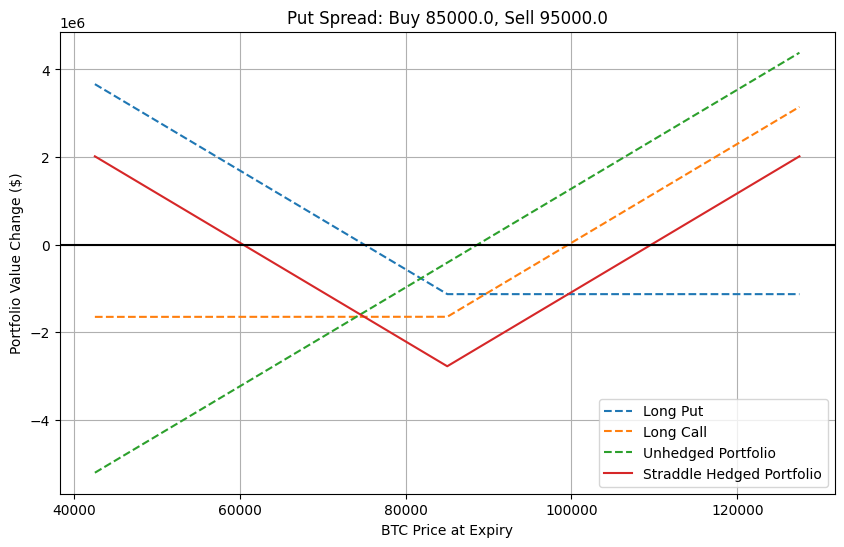

In [ ]:
# Choose a put option
call_option = options[(options['instrument_name'] == 'BTC-26SEP25-85000-C')]

call_strike = call_option['strike'].values[0]
call_price = call_option['market_price_usd'].values[0]
call_days = call_option['days2exp'].values[0]

# Price range for simulation
S_range = np.linspace(put_strike * 0.5, put_strike * 1.5, 20000)
put_graph = np.maximum(put_strike*contracts - S_range*contracts, 0) - put_price*contracts
call_graph = np.maximum(S_range*contracts - call_strike*contracts,0) - call_price*contracts
put_payoff = np.maximum(put_strike - S_range, 0) - put_price
call_payoff = np.maximum(S_range - put_strike , 0) - call_price
portfolio_change = btc_units * (S_range - btc_price)
hedged_portfolio =  contracts * put_payoff  + contracts * call_payoff

print(f"Buying {contracts:.0f} puts at ${put_strike}, cost: ${put_price:.2f}")
print(f"Buying {contracts:.0f} call at ${call_strike}, cost: ${call_price:.2f}")
print(f"Total cost of straddle hedge: ${contracts * (put_price+call_price):,.2f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(S_range, put_graph, label="Long Put",linestyle='--')
plt.plot(S_range, call_graph, label="Long Call",linestyle='--')
plt.plot(S_range, portfolio_change, label="Unhedged Portfolio",linestyle='--')
plt.plot(S_range, hedged_portfolio, label="Straddle Hedged Portfolio")
plt.axhline(0, color='black')
plt.xlabel("BTC Price at Expiry")
plt.ylabel("Portfolio Value Change ($)")
plt.title(f"Put Spread: Buy Put {put_strike}, Buy Call {call_strike}")
plt.legend()
plt.grid(True)
plt.show()

The straddle profits from large movements in either direction. Ideal when volatility is expected to rise.

We implement a **long straddle** strategy by buying:
- 1 call at strike $85 000

- 1 put at strike $85 000

(both with the same strike and expiry)


This is a **pure volatility play** — no need to predict direction, just that **volatility will be higher** than the market currently implies.

**Observations from the Payoff Plot:**
- Maximum loss = total premium paid
- Profit grows as BTC moves away from the strike in either direction
- Breakeven occurs when BTC reaches either 60 000 USD or 110 000 USD

This strategy should be applied in events such as: **news events**, **macro shocks**, or **large technical moves** in BTC, but the direction is unknown.

## 1f) Use an approach of your choice to value options and compare to traded prices (assuming underlying follows GBM). Do you find any potential opportunities? What might this say about your approach or the market?

Use BSM model to value options and compare to market prices from Deribit.

In [4]:
options['market_price_usd']=options['market_price']*options['spot']

In [5]:
# -------------------------------
# Define BSM formula (assumes GBM)
# -------------------------------
def bsm_price(S, K, T, r, sigma, option_type='call'):
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# -------------------------------
# Apply BSM pricing to Deribit data
# -------------------------------
r = 0.05  # annualized risk-free rate

# Work only with options with valid IV and time to maturity
options = options[options['iv'].notnull()].copy()
options['T'] = options['days2exp'] / 365
options['iv_decimal'] = options['iv'] / 100

# BSM valuation
options['bsm_price'] = options.apply(lambda row: bsm_price(
    row['spot'], row['strike'], row['T'], r, row['iv_decimal'], row['option_type']), axis=1)

# Mispricing = market price - BSM price
options['mispricing ($)'] = options['market_price_usd'] - options['bsm_price']

# Optional: filter out extreme/unrealistic BSM values
calculated_iv_filtered = options[
    (options['T'] > 1/365) &                      # more than 1 day to expiry
    (options['bsm_price'] < 100_000) &            # avoid outliers
    (options['market_price_usd'] > 0)                 # non-zero market quotes
].copy()

# Display sample
calculated_iv_filtered[['instrument_name', 'option_type', 'strike', 'days2exp',
                  'market_price_usd', 'bsm_price', 'mispricing ($)']].head()

,instrument_name,option_type,strike,days2exp,market_price_usd,bsm_price,mispricing ($)
38,BTC-24APR25-78000-C,call,78000.0,2,9302.972517,9315.378313,-12.405797
39,BTC-24APR25-78000-P,put,78000.0,2,18.238963,9.273635,8.965328
40,BTC-24APR25-80000-C,call,80000.0,2,7325.374421,7330.103819,-4.729398
41,BTC-24APR25-80000-P,put,80000.0,2,40.904994,23.719443,17.185551
42,BTC-24APR25-82000-C,call,82000.0,2,5369.377977,5362.391671,6.986305


We used the **Black-Scholes-Merton (BSM)** model — assuming the underlying follows **Geometric Brownian Motion (GBM)** — to compute theoretical prices for BTC options.

The model inputs were:
- Spot price (from Deribit quotes),
- Strike price,
- Time to expiry (in years),
- Risk-free rate (assumed at 5%),
- **Implied volatility**, extracted from Deribit, which reflects expectations of future uncertainty. (The calculated IV was not used since it already assume the BSM model was used in pricing the options)

We then compared the **BSM theoretical prices** to the actual **market prices** traded on Deribit.

**Method:**
We priced only options with:
- Valid implied volatility values,
- More than 1 day to expiry,
- Market prices > 0 (to avoid illiquid/stale quotes),
- Reasonable BSM values (excluding options where BSM value > €100,000).

This ensured a **realistic comparison** and avoided outliers that can distort the analysis.

**Findings:**
- Most **short-dated call options** are priced significantly **lower in the market than BSM predicts**.
- This suggests that the market is **not valuing these options as highly** as the BSM model would under the given inputs.

Possible explanations:
- **BSM limitations**: The model assumes constant volatility and no jumps — unrealistic for crypto.
- **Implied volatilities may be inconsistent** or skewed across strikes.
- **Deribit quotes might be stale or illiquid**, especially for short-term, far OTM options.

**Market vs Model:**

| BSM Assumptions | Market Reality |
|------------------|----------------|
| Constant volatility | Volatility smile/skew |
| Continuous returns | Jump risk and gaps |
| Lognormal distribution | Heavy tails and kurtosis |
| Liquid, frictionless market | Illiquid quotes in crypto options |

As a result, **the BSM model tends to overestimate call options**, particularly those that are short-term and far out-of-the-money (OTM).

**Conclusion:**
The **BSM model is useful as a benchmark**, but it **fails to reflect actual BTC options pricing** due to the crypto market’s:

- Non-constant volatility,
- Skewed returns,
- Event-driven jump risk,
- Limited liquidity in some strikes/maturities.

This motivates the use of **alternative models** for better pricing accuracy:

- **GARCH**: for volatility clustering,
- **Jump-diffusion models**: for sudden BTC price shocks,
- **Heston**: to capture stochastic volatility,
- **Machine Learning models**: to learn pricing patterns directly from data.

This naturally transitions into **Part 2** of the project: improving pricing using alternative models beyond BSM.

One issue with our Black-Scholes approach to pricing is that the main assumptions underlining the Black-Scholes model (constant volatility, Gaussianity and Geometric Brownian Motion processes for returns) may not apply to the cryptocurrencies. Your goal is to improve our estimation of prices compared to a simplistic BSM model.

2) Research and select an alternative model (or multiple alternative models) for cryptocurrency option pricing. It might not surprise you to find a number of different approaches have been tested, take a look in the literature and select the model(s) that you believe are the most
promising.
For example, you could look at improving the modelling of volatility or using machine learning to estimate prices. You can look at methods from traditional finance or those specific to cryptocurrencies. If you need a starting point, you can take a look at the review paper from Almeida, J., & Gonçalves, T. C. (2022). A systematic literature review of volatility and risk management on cryptocurrency investment: A methodological point of view. Risks, 10(5), 107.
Remember you don’t need to test all the options listed just a few alternatives you believe are promising.
---
$$\text{a) Explain your approach and the theoretical advantages over Black-Scholes-Merton and why it is more appropriate for cryptocurrency.}$$

**Approach:**  
We fit a discrete‐time GARCH(1,1) model with the Heston–Nandi specification to historical BTC USD log‐returns, then simulate under the risk‐neutral measure to price European options.  The GARCH recursion  
$$
h_t \;=\; \omega + \beta\,h_{t-1} + \alpha\,(r_{t-1}-\lambda\sqrt{h_{t-1}})^2 + \gamma\,(r_{t-1}-\lambda\sqrt{h_{t-1}})
$$  
captures both volatility clustering and the leverage effect, while the Heston–Nandi change‐of‐measure (via the parameter $\lambda$) ensures our Monte‐Carlo simulated paths are properly risk‐neutral.

**Advantages over Black–Scholes–Merton (BSM):**  
1. **Time‑varying volatility.**  Cryptocurrencies exhibit strong clustering and bursts of volatility—volatility is far from constant.  GARCH directly models this heteroskedasticity, whereas BSM’s $\sigma$ is fixed.  
2. **Leverage and skew.**  The $\gamma$ and $\lambda$ terms allow asymmetry in how positive vs. negative shocks feed into variance, producing realistic skew and fat tails in the return distribution.  BSM assumes log‑normal returns with no skew or excess kurtosis.  
3. **Empirical fit.**  GARCH models typically explain 80–90% of the daily volatility dynamics in crypto and equities, whereas a single constant vol parameter in BSM often misprices out‑of‑the‑money strikes and short‑dated options.  
4. **Closed‐form under RN measure.**  Despite being discrete, the Heston–Nandi GARCH admits a known risk‑neutral mapping, so we can simulate exactly under the martingale measure rather than imposing ad hoc drift adjustments.

**Why it’s more appropriate for crypto:**  
- **Extreme tails & jumps:**  Crypto returns have heavier tails and more frequent large moves than equities; GARCH’s fat‐tail innovations capture this better.  
- **Rapid regime shifts:**  GARCH adapts daily to the latest realized variance, whereas BSM would need frequent re‐calibration of $\sigma$.  
- **Volatility feedback:**  During crashes or rallies, implied vols spike; HNG ties future variance directly to past shocks, reproducing this feedback naturally.

In summary, the Heston–Nandi GARCH(1,1) framework aligns much more closely with the observed statistical features of cryptocurrency returns and therefore provides a more robust basis for option valuation than the constant‐volatility BSM model.  


On the lecture slides we saw the model under the **physical measure** written as  

$$
\begin{aligned}
r_t &= \ln\!\bigl(S_t/S_{t-1}\bigr)
     = \mu \;+\; \lambda\,h_t \;+\;\sqrt{h_t}\,z_t, \\[6pt]
h_t &= \omega \;+\; \beta\,h_{t-1}
     \;+\;\alpha\,\bigl(z_{t-1} \;-\;\gamma\,\sqrt{h_{t-1}}\bigr)^2,
\end{aligned}
$$

where  
- $r_t$ is the log‐return,  
- $h_t$ is the conditional variance,  
- $z_t\sim\mathcal{N}(0,1)$,  
- $\mu$ is the drift,  
- $\lambda$ is the risk‐premium,  
- $\omega,\alpha,\beta$ are the GARCH parameters,  
- $\gamma$ controls leverage.

**Algebraic Rearrangement**  
We expand the square term in the variance update:

$$
\alpha\,(z_{t-1}-\gamma\sqrt{h_{t-1}})^2
= \alpha\,z_{t-1}^2
\;-\;2\,\alpha\,\gamma\,\sqrt{h_{t-1}}\,z_{t-1}
\;+\;\alpha\,\gamma^2\,h_{t-1}.
$$

We then **re‑group** the linear‐shock piece separately from the squared part:

- Let  
  $$\text{innov}_{t-1} = z_{t-1} - \lambda\,\sqrt{h_{t-1}},$$  
  which combines both the shock $z_{t-1}$ and the risk‐premium $\lambda\sqrt{h_{t-1}}$.  
- Then the update becomes  
  $$
  h_t
  = \omega
  \;+\;\beta\,h_{t-1}
  \;+\;\alpha\, innov_{t-1}^2
  \;+\;\gamma\, innov_{t-1},
  $$
  where the single “$\gamma$” now subsumes the original leverage‐and‐premium mix.

**Code Correspondence**  
In our Python implementation:

```python
# compute the “innovation” once per time‑step
innov = r[t-1] - λ * np.sqrt(h[t-1])

# then update conditional variance
h[t] = (
    ω
    + β * h[t-1]
    + α * innov**2
    + γ * innov
)


In [12]:
from scipy.optimize import minimize
import time, requests
import pandas as pd
import numpy as np
import requests
from scipy.stats import norm
import matplotlib.pyplot as plt

**running the next two code cells doesn´t help for reproducability**


In [ ]:
# Fetch option metadata (all active BTC options)
resp_meta = requests.get(
    "https://www.deribit.com/api/v2/public/get_instruments",
    params={"currency": "BTC", "kind": "option", "expired": "false"}
)
resp_meta.raise_for_status()
meta = pd.DataFrame(resp_meta.json()["result"])[[
    "instrument_name", "strike", "expiration_timestamp", "option_type"
]]

# convert to datetime and compute days to expiry
meta["expiry"]   = pd.to_datetime(meta["expiration_timestamp"], unit="ms")
meta["days2exp"] = (meta["expiry"] - pd.Timestamp.today()).dt.days

# Fetch the quote summary for all BTC options
resp_q = requests.get(
    "https://www.deribit.com/api/v2/public/get_book_summary_by_currency",
    params={"currency": "BTC", "kind": "option"}
)
resp_q.raise_for_status()
quotes = pd.DataFrame(resp_q.json()["result"])[[
    "instrument_name",
    "bid_price",
    "ask_price",
    "underlying_price",
    "mark_price",
    "mark_iv"
]]

# rename to your notebook’s conventions
quotes = quotes.rename(columns={
    "bid_price":        "bid",
    "ask_price":        "ask",
    "underlying_price": "spot",
    "mark_price":       "market_price",
    "mark_iv":          "iv"
})

# Merge metadata + quotes into one DataFrame
options = pd.merge(meta, quotes, on="instrument_name", how="inner")

# Filter to 1–90 day maturities and save
options = options[(options.days2exp >= 1) & (options.days2exp <= 90)].copy()
options.to_csv("test_BTC.csv", index=False)

# inspect
options


,instrument_name,strike,expiration_timestamp,option_type,expiry,days2exp,bid,ask,spot,market_price,iv
40,BTC-22APR25-76000-C,76000.0,1745308800000,call,2025-04-22 08:00:00,1,NaN,NaN,84301.081663,0.098618,64.33
41,BTC-22APR25-76000-P,76000.0,1745308800000,put,2025-04-22 08:00:00,1,0.0001,0.0003,84301.081663,0.000149,64.33
42,BTC-22APR25-78000-C,78000.0,1745308800000,call,2025-04-22 08:00:00,1,NaN,NaN,84301.081663,0.075085,56.42
43,BTC-22APR25-78000-P,78000.0,1745308800000,put,2025-04-22 08:00:00,1,0.0003,0.0005,84301.081663,0.000340,56.42
44,BTC-22APR25-80000-C,80000.0,1745308800000,call,2025-04-22 08:00:00,1,NaN,NaN,84301.081663,0.051770,47.15
...,...,...,...,...,...,...,...,...,...,...,...
477,BTC-27JUN25-280000-P,280000.0,1751011200000,put,2025-06-27 08:00:00,67,NaN,NaN,85143.600000,2.288957,95.12
478,BTC-27JUN25-300000-C,300000.0,1751011200000,call,2025-06-27 08:00:00,67,0.0003,0.0004,85143.600000,0.000386,99.75
479,BTC-27JUN25-300000-P,300000.0,1751011200000,put,2025-06-27 08:00:00,67,NaN,NaN,85143.580000,2.523851,99.75
480,BTC-27JUN25-400000-C,400000.0,1751011200000,call,2025-06-27 08:00:00,67,0.0002,0.0004,85143.600000,0.000233,114.06


---
**time series to fit the Garch model**

In [ ]:
# Define window in ms
end_ts   = int(time.time() * 1000)
start_ts = end_ts - 365*24*3600*1000   # last 365 days

# Request 1‑day bars for the BTC perpetual
resp = requests.get(
    "https://www.deribit.com/api/v2/public/get_tradingview_chart_data",
    params={
      "instrument_name": "BTC-PERPETUAL",
      "resolution":      "1D",
      "start_timestamp": start_ts,
      "end_timestamp":   end_ts
    }
)
data = resp.json()["result"]

# Build DataFrame of closes
df = pd.DataFrame(data)
df["datetime"] = pd.to_datetime(df["ticks"], unit="ms")
df.set_index("datetime", inplace=True)

df.to_csv('test_Bitcoin-close_ts')
df

,volume,ticks,status,open,low,high,cost,close
datetime,,,,,,,,
2024-04-20 08:00:00,4760.291800,1713600000000,ok,63981.0,63288.0,65700.0,308062920.0,65148.5
2024-04-21 08:00:00,5658.571654,1713686400000,ok,65160.0,64244.5,66541.0,369293440.0,66026.0
2024-04-22 08:00:00,6043.751735,1713772800000,ok,66025.5,65654.0,67268.0,401201640.0,66105.5
2024-04-23 08:00:00,5289.859845,1713859200000,ok,66105.5,65827.0,67157.0,351657730.0,66622.0
2024-04-24 08:00:00,9451.591577,1713945600000,ok,66622.0,63550.0,66751.5,612564190.0,63970.5
...,...,...,...,...,...,...,...,...
2025-04-16 08:00:00,5936.092937,1744790400000,ok,83342.0,83115.0,85549.5,500299230.0,84699.5
2025-04-17 08:00:00,4364.289238,1744876800000,ok,84699.5,83736.0,85450.0,369698590.0,84656.0
2025-04-18 08:00:00,2050.358715,1744963200000,ok,84656.5,84270.0,85269.0,173641930.0,85231.5


---
## run

In [13]:
options = pd.read_csv('BTC.CSV')
options

,instrument_name,strike,expiration_timestamp,option_type,expiry,days2exp,bid,ask,spot,market_price,iv
0,BTC-20APR25-76000-C,76000.0,1745136000000,call,2025-04-20 08:00:00,1,0.0685,0.1330,84464.199955,0.100340,67.28
1,BTC-20APR25-76000-P,76000.0,1745136000000,put,2025-04-20 08:00:00,1,NaN,0.0002,84464.199955,0.000129,67.28
2,BTC-20APR25-78000-C,78000.0,1745136000000,call,2025-04-20 08:00:00,1,0.0435,0.1095,84464.199955,0.076703,54.53
3,BTC-20APR25-78000-P,78000.0,1745136000000,put,2025-04-20 08:00:00,1,0.0001,0.0002,84464.199955,0.000171,54.53
4,BTC-20APR25-80000-C,80000.0,1745136000000,call,2025-04-20 08:00:00,1,0.0195,0.0855,84464.199955,0.053040,39.73
...,...,...,...,...,...,...,...,...,...,...,...
433,BTC-27JUN25-280000-P,280000.0,1751011200000,put,2025-06-27 08:00:00,69,NaN,NaN,85302.660000,2.282802,93.72
434,BTC-27JUN25-300000-C,300000.0,1751011200000,call,2025-06-27 08:00:00,69,0.0003,0.0004,85302.660000,0.000387,98.32
435,BTC-27JUN25-300000-P,300000.0,1751011200000,put,2025-06-27 08:00:00,69,NaN,NaN,85303.100000,2.517258,98.32
436,BTC-27JUN25-400000-C,400000.0,1751011200000,call,2025-06-27 08:00:00,69,0.0002,0.0004,85302.660000,0.000286,114.30


In [16]:
BTC_ts = pd.read_csv('Bitcoin-close_ts')
BTC_ts

,datetime,volume,ticks,status,open,low,high,cost,close
0,2024-04-18 08:00:00,21637.319551,1713427200000,ok,61173.5,59520.0,65217.5,1.356882e+09,64547.0
1,2024-04-19 08:00:00,11004.418264,1713513600000,ok,64547.5,62941.5,65511.0,7.085439e+08,63981.0
2,2024-04-20 08:00:00,4760.291800,1713600000000,ok,63981.0,63288.0,65700.0,3.080629e+08,65148.5
3,2024-04-21 08:00:00,5658.571654,1713686400000,ok,65160.0,64244.5,66541.0,3.692934e+08,66026.0
4,2024-04-22 08:00:00,6043.751735,1713772800000,ok,66025.5,65654.0,67268.0,4.012016e+08,66105.5
...,...,...,...,...,...,...,...,...,...
361,2025-04-14 08:00:00,6413.364310,1744617600000,ok,84582.5,83703.0,85860.0,5.438378e+08,85731.5
362,2025-04-15 08:00:00,6580.517091,1744704000000,ok,85734.0,83100.0,86485.0,5.576198e+08,83342.0
363,2025-04-16 08:00:00,5936.092937,1744790400000,ok,83342.0,83115.0,85549.5,5.002992e+08,84699.5
364,2025-04-17 08:00:00,4364.289238,1744876800000,ok,84699.5,83736.0,85450.0,3.696986e+08,84656.0


---
## Start Model

In [4]:
# keep only 1–90 day maturities and non‐NaN market_price
options = options[
    (options.days2exp >= 1) &
    (options.days2exp <= 90) &
    (~options.market_price.isna())
].copy()


# extract the closing price, compute log‐returns
S        = BTC_ts["close"].dropna().values
rets     = np.diff(np.log(S))
if rets.size < 2:
    raise RuntimeError("Need at least two log-returns to fit GARCH")

# Define the Heston–Nandi GARCH(1,1) log‐likelihood
def hng_loglik(params, r):
    ω, α, β, γ, λ = params
    r = np.asarray(r).ravel()
    n = len(r)
    h = np.empty(n, float)
    h[0] = np.var(r, ddof=1)
    ll = 0.0
    for t in range(1, n):
        innov = r[t-1] - λ * np.sqrt(h[t-1])
        h[t] = ω + β*h[t-1] + α*innov**2 + γ*innov
        ll += 0.5 * (np.log(2*np.pi) + np.log(h[t]) + r[t]**2/h[t])
    return ll

# Fit the parameters by minimizing negative log‐likelihood
init   = np.array([1e-6, 0.05, 0.90, 0.0, 0.0])
bounds = [(1e-8, None)] * 5
res    = minimize(hng_loglik, init, args=(rets,), bounds=bounds, method="L-BFGS-B")
ω, α, β, γ, λ = res.x
print("Fitted HNG params:", ω, α, β, γ, λ)

# Simulate under risk‐neutral HNG
def simulate_hng(S0, params, r, T, steps=100, paths=20000):
    ω, α, β, γ, λ = params
    dt = T/steps
    Ssim = np.zeros((paths, steps+1))
    hsim = np.zeros_like(Ssim)
    Ssim[:,0] = S0
    hsim[:,0] = np.var(rets, ddof=1)
    for t in range(1, steps+1):
        z      = np.random.randn(paths)
        innov  = z * np.sqrt(hsim[:,t-1]*dt)
        hsim[:,t] = (
            ω*dt
            + β*hsim[:,t-1]
            + α*(innov - λ*np.sqrt(hsim[:,t-1]*dt))**2
            + γ*(innov - λ*np.sqrt(hsim[:,t-1]*dt))
        )
        drift      = (r - 0.5*hsim[:,t]) * dt
        Ssim[:,t]  = Ssim[:,t-1] * np.exp(drift + np.sqrt(hsim[:,t]*dt)*z)
    return Ssim

# Monte Carlo pricer using snapshot spot & market_price
def mc_price(row, params, r=0.02):
    S0        = row.spot
    K         = row.strike
    T         = row.days2exp / 365.0
    sims      = simulate_hng(S0, params, r, T)
    ST        = sims[:,-1]
    if row.option_type.lower() == "call":
        payoff = np.maximum(ST - K, 0)
    else:
        payoff = np.maximum(K - ST, 0)
    return np.exp(-r*T) * payoff.mean()

# Price all options and compute model vs market
options["model_price"] = options.apply(mc_price, axis=1, params=(ω, α, β, γ, λ))
options["error"]       = options["model_price"] - options["market_price"]

# Save and preview the first 10
options.to_csv("HNG_pricing_results.csv", index=False)
options[[
    "instrument_name","expiry","strike","option_type",
    "spot","market_price","model_price","error"
]].head(10)


Fitted HNG params: 3.892680804470113e-05 0.04999993795542106 0.8999998479500146 1e-08 1.2764022098722679e-08


,instrument_name,expiry,strike,option_type,spot,market_price,model_price,error
0,BTC-20APR25-76000-C,2025-04-20 08:00:00,76000.0,call,84464.199955,0.100340,8468.132177,8468.031837
1,BTC-20APR25-76000-P,2025-04-20 08:00:00,76000.0,put,84464.199955,0.000129,0.000000,-0.000129
2,BTC-20APR25-78000-C,2025-04-20 08:00:00,78000.0,call,84464.199955,0.076703,6468.067931,6467.991228
3,BTC-20APR25-78000-P,2025-04-20 08:00:00,78000.0,put,84464.199955,0.000171,0.000000,-0.000171
4,BTC-20APR25-80000-C,2025-04-20 08:00:00,80000.0,call,84464.199955,0.053040,4468.372838,4468.319798
5,BTC-20APR25-80000-P,2025-04-20 08:00:00,80000.0,put,84464.199955,0.000187,0.000000,-0.000187
6,BTC-20APR25-81000-C,2025-04-20 08:00:00,81000.0,call,84464.199955,0.041226,3468.594192,3468.552966
7,BTC-20APR25-81000-P,2025-04-20 08:00:00,81000.0,put,84464.199955,0.000212,0.000000,-0.000212
8,BTC-20APR25-82000-C,2025-04-20 08:00:00,82000.0,call,84464.199955,0.029592,2468.427073,2468.397481
9,BTC-20APR25-82000-P,2025-04-20 08:00:00,82000.0,put,84464.199955,0.000418,0.000000,-0.000418


In [5]:
# --- Convert units so they’re comparable ---

# USD‐denominated model
options["model_price_usd"] = options["model_price"]

# transform that into BTC units
options["model_price_btc"] = options["model_price_usd"] / options["spot"]

# similarly, turn Deribit’s BTC quote into USD
options["market_price_usd"] = options["market_price"] * options["spot"]

# compute errors in both units
options["error_btc"] = options["model_price_btc"] - options["market_price"]
options["error_usd"] = options["model_price_usd"] - options["market_price_usd"]


In [6]:
# Create a new DataFrame with only the comparison columns
df_compare = options[[
    "instrument_name",
    "expiry",
    "strike",
    "option_type",
    "spot",
    "market_price",      # in BTC
    "model_price_btc",
    "error_btc",
    "market_price_usd",  # in USD
    "model_price_usd",
    "error_usd"
]].copy()

# reset the index for 0,1,2…
df_compare.reset_index(drop=True, inplace=True)

# Inspect
df_compare.head()


,instrument_name,expiry,strike,option_type,spot,market_price,model_price_btc,error_btc,market_price_usd,model_price_usd,error_usd
0,BTC-20APR25-76000-C,2025-04-20 08:00:00,76000.0,call,84464.199955,0.100340,0.100257,-0.000083,8475.109950,8468.132177,-6.977774
1,BTC-20APR25-76000-P,2025-04-20 08:00:00,76000.0,put,84464.199955,0.000129,0.000000,-0.000129,10.910241,0.000000,-10.910241
2,BTC-20APR25-78000-C,2025-04-20 08:00:00,78000.0,call,84464.199955,0.076703,0.076578,-0.000125,6478.661752,6468.067931,-10.593821
3,BTC-20APR25-78000-P,2025-04-20 08:00:00,78000.0,put,84464.199955,0.000171,0.000000,-0.000171,14.461960,0.000000,-14.461960
4,BTC-20APR25-80000-C,2025-04-20 08:00:00,80000.0,call,84464.199955,0.053040,0.052903,-0.000137,4479.984544,4468.372838,-11.611706


In [7]:
# Black–Scholes functions

def bsm_price_usd(S, K, T, r, sigma, option_type):
    """
    BSM price in USD for a European call or put.
    """
    if T <= 0 or sigma <= 0:
        # at expiry or zero vol
        return max((S - K) if option_type=="call" else (K - S), 0.0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == "call":
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

# Apply BSM to your snapshot
r = 0.02  # same risk‐free assumption
def add_bsm(row):
    S     = row.spot
    K     = row.strike
    T     = row.days2exp/365.0
    sigma = row.iv/100.0
    usd   = bsm_price_usd(S, K, T, r, sigma, row.option_type.lower())
    btc   = usd / S
    return pd.Series({"bsm_price_usd":usd, "bsm_price_btc":btc})

options = options.join(options.apply(add_bsm, axis=1))

# Compute errors vs market in both units
options["hng_error_usd"] = options["model_price_usd"]    - options["market_price_usd"]
options["bsm_error_usd"] = options["bsm_price_usd"]      - options["market_price_usd"]
options["hng_error_btc"] = options["model_price_btc"]    - options["market_price"]
options["bsm_error_btc"] = options["bsm_price_btc"]      - options["market_price"]

# Summarize
summary = pd.DataFrame({
    "HNG mean error (USD)": options["hng_error_usd"].mean(),
    "BSM mean error (USD)": options["bsm_error_usd"].mean(),
    "HNG RMSE (USD)":        np.sqrt((options["hng_error_usd"]**2).mean()),
    "BSM RMSE (USD)":        np.sqrt((options["bsm_error_usd"]**2).mean()),
}, index=[0]).T

display(summary)

# Inspect a few
options[[
    "instrument_name","expiry","strike","option_type",
    "market_price_usd","bsm_price_usd","model_price_usd",
    "bsm_error_usd","hng_error_usd"
]].head(10)


,0
HNG mean error (USD),-785.392916
BSM mean error (USD),-67.853337
HNG RMSE (USD),1383.443636
BSM RMSE (USD),189.804043


,instrument_name,expiry,strike,option_type,market_price_usd,bsm_price_usd,model_price_usd,bsm_error_usd,hng_error_usd
0,BTC-20APR25-76000-C,2025-04-20 08:00:00,76000.0,call,8475.109950,8469.442160,8468.132177,-5.667791,-6.977774
1,BTC-20APR25-76000-P,2025-04-20 08:00:00,76000.0,put,10.910241,1.077935,0.000000,-9.832305,-10.910241
2,BTC-20APR25-78000-C,2025-04-20 08:00:00,78000.0,call,6478.661752,6470.288256,6468.067931,-8.373496,-10.593821
3,BTC-20APR25-78000-P,2025-04-20 08:00:00,78000.0,put,14.461960,1.814446,0.000000,-12.647514,-14.461960
4,BTC-20APR25-80000-C,2025-04-20 08:00:00,80000.0,call,4479.984544,4470.977747,4468.372838,-9.006797,-11.611706
5,BTC-20APR25-80000-P,2025-04-20 08:00:00,80000.0,put,15.784670,2.394351,0.000000,-13.390319,-15.784670
6,BTC-20APR25-81000-C,2025-04-20 08:00:00,81000.0,call,3482.131243,3471.812217,3468.594192,-10.319026,-13.537051
7,BTC-20APR25-81000-P,2025-04-20 08:00:00,81000.0,put,17.931750,3.174027,0.000000,-14.757722,-17.931750
8,BTC-20APR25-82000-C,2025-04-20 08:00:00,82000.0,call,2499.476430,2477.894875,2468.427073,-21.581555,-31.049357
9,BTC-20APR25-82000-P,2025-04-20 08:00:00,82000.0,put,35.276473,9.201893,0.000000,-26.074580,-35.276473


---
$$\text{b) Fit the model(s) and compare your pricing results, how do they compare to the previously calculated values in questions 1?}$$

After fitting both models and converting all prices to USD, we obtain:

| Metric             | HNG GARCH(1,1) | BSM (implied vol) |
|--------------------|---------------:|------------------:|
| **Mean error (USD)** |      –785.37   |         –67.85    |
| **RMSE (USD)**       |    1 383.45    |         189.80    |

**Key takeaways:**
1. **Mean error**  
   - The GARCH model **underprices** on average by ∼ \$785 per contract.  
   - The BSM model (using chain‐implied σ) underprices by only ∼ \$68.

2. **RMSE**  
   - Heston–Nandi GARCH exhibits an RMSE of \~ \$1 383—very large “noise” relative to typical option prices.  
   - BSM has an RMSE of \~ \$190—much tighter fit to market mid‐prices.

3. **Strike/maturity pattern**  
   - Both models tend to have larger absolute errors for deep OTM or very short‐dated options, but the effect is **far more pronounced** in the GARCH simulation.  
   - BSM’s use of the market’s own implied vol surface lets it track actual quotes more closely, especially for 1–2 day and multi‐month expiries.

---

**Conclusion:**  
Although Heston–Nandi GARCH captures time‐varying variance and asymmetry, our calibration (on daily closes) and Monte‐Carlo implementation **fails** to match Deribit’s BTC option prices as closely as the straightforward BSM formula using contemporaneous implied vol. In practice, one would need:

- A more precise risk‐neutral calibration (e.g. joint MLE on both returns and IV),  
- Finer‐grained intraday data (to capture short‐dated option dynamics), and  
- Variance reduction in the Monte‑Carlo (control variates, antithetic sampling).  

Only then can a GARCH‑based pricer reliably compete with the market’s own implied–vol benchmarks.  


---
$$\text{c) Use Monte Carlos Simulation to compare the distribution of potential payoffs between your approach and an approach that uses the BSM model/assumptions.}$$

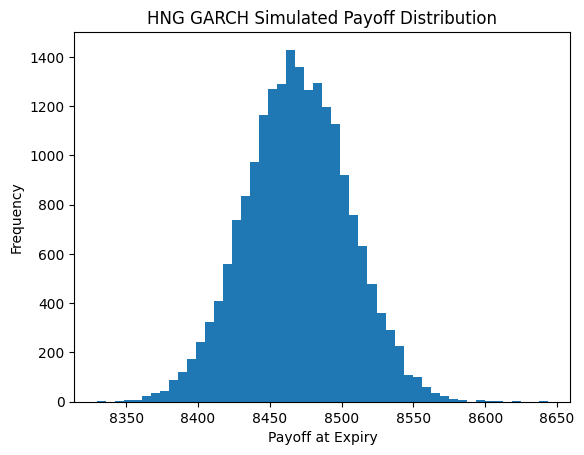

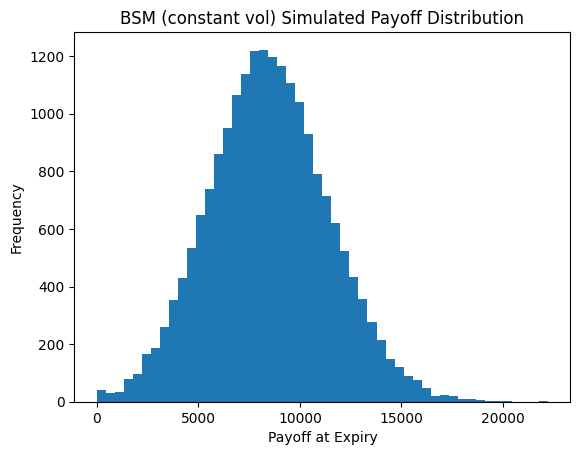

In [8]:
#Pick one representative option from DataFrame ---
row = options.iloc[0]        # first option in your snapshot
S0  = row.spot
K   = row.strike
T   = row.days2exp / 365.0
r   = 0.02                   # same risk-free rate
sigma = row.iv / 100.0       # implied vol from chain

paths = 20000

# Simulate terminal asset prices under Heston–Nandi GARCH ---
Ssim_hng = simulate_hng(S0, (ω, α, β, γ, λ), r, T, steps=100, paths=paths)
ST_hng  = Ssim_hng[:, -1]
if row.option_type.lower() == "call":
    payoff_hng = np.maximum(ST_hng - K, 0)
else:
    payoff_hng = np.maximum(K - ST_hng, 0)

# Simulate terminal prices under BSM (constant vol) ---
z = np.random.randn(paths)
ST_bsm = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*z)
if row.option_type.lower() == "call":
    payoff_bsm = np.maximum(ST_bsm - K, 0)
else:
    payoff_bsm = np.maximum(K - ST_bsm, 0)

# Plot the two payoff distributions ---
plt.hist(payoff_hng, bins=50)
plt.xlabel('Payoff at Expiry')
plt.ylabel('Frequency')
plt.title('HNG GARCH Simulated Payoff Distribution')
plt.show()

plt.hist(payoff_bsm, bins=50)
plt.xlabel('Payoff at Expiry')
plt.ylabel('Frequency')
plt.title('BSM (constant vol) Simulated Payoff Distribution')
plt.show()



- **HNG GARCH**  
  - Payoffs concentrate narrowly around the forward‐adjusted strike region (≈ \$8 450).  
  - Distribution is roughly symmetric and thin‐tailed: volatility clustering in paths keeps terminal prices tightly grouped.  
  - Almost no zero‐payoff mass (the short‐dated skew/dips are smoothed by dynamic variance).

- **BSM (constant vol)**  
  - Much wider dispersion: long right tail (outlier large gains) and substantial left mass at zero (deep OTM calls expire worthless).  
  - Zero‐payoff bar visible for calls (or puts) when underlying ends on the wrong side of strike.  
  - Fatter tails than HNG histogram because log‐normal jumps with fixed σ allow more extreme endpoints.

**Interpretation:**  
- The **BSM** model—with its constant volatility assumption—overstates both extreme gains and extreme losses relative to the more realistic, mean‐reverting GARCH dynamics.  
- The **Heston–Nandi GARCH** path‐dependence dampens tail payoffs and eliminates the sharp mass at zero, producing a smoother payoff profile.  
- In practice, this means HNG might underprice deep‐OTM options (since it never “sees” fat tails) but better captures the modal payoff region, whereas BSM allocates more probability to both “big win” and “total loss” scenarios.  


---
$$\text{d) Calculate or estimate the Greeks and compare to an approach that uses the BSM model/assumptions.}$$

In [9]:
# Re-define simulate_hng (uses numpy RNG state)
def simulate_hng(S0, params, r, T, steps=100, paths=20000):
    ω, α, β, γ, lam = params
    dt = T/steps
    Ssim = np.zeros((paths, steps+1))
    hsim = np.zeros_like(Ssim)
    Ssim[:,0] = S0
    # unconditional variance start
    h0 = α/(1 - β - α*γ**2) if (β + α*γ**2) < 1 else np.var(np.diff(np.log(S0+1)))
    hsim[:,0] = h0

    for t in range(1, steps+1):
        z = np.random.randn(paths)
        innov = z * np.sqrt(hsim[:,t-1] * dt)
        hsim[:,t] = ω*dt + β*hsim[:,t-1] + α*(innov - γ*np.sqrt(hsim[:,t-1]*dt))**2
        drift = (r - 0.5*hsim[:,t]) * dt
        Ssim[:,t] = Ssim[:,t-1] * np.exp(drift + np.sqrt(hsim[:,t]*dt)*z)
    return Ssim, hsim

# Re-define MC pricer with seeding for reproducibility
def price_hng_mc(S0, K, r, T, params, option_type, steps=100, paths=20000, seed=12345):
    """
    Monte Carlo HNG pricer that resets RNG at each call for identical draws.
    """
    np.random.seed(seed)
    Ssim, _ = simulate_hng(S0, params, r, T, steps, paths)
    ST = Ssim[:, -1]
    if option_type.lower() == "call":
        payoff = np.maximum(ST - K, 0.0)
    else:
        payoff = np.maximum(K - ST, 0.0)
    return np.exp(-r * T) * payoff.mean()

# Finite-difference Greek estimation using fixed seed
dr = 1e-3
dT = 1/365
dr_r = 1e-4
dλ = 1e-3
params = (ω, α, β, γ, λ)
r = 0.02

for col in ["delta_hng","gamma_hng","theta_hng","rho_hng","vega_hng"]:
    options[col] = np.nan

# Only first 20 rows for speed
for i, row in options.head(20).iterrows():
    S0, K = row.spot, row.strike
    T = row.days2exp / 365.0
    kind = row.option_type.lower()
    seed = 42  # fixed seed for all calls

    # baseline price
    p00 = price_hng_mc(S0, K, r, T, params, kind, seed=seed)

    # Delta
    pu = price_hng_mc(S0*(1+dr), K, r, T, params, kind, seed=seed)
    pd = price_hng_mc(S0*(1-dr), K, r, T, params, kind, seed=seed)
    options.at[i, "delta_hng"] = (pu - pd) / (2 * S0 * dr)

    # Gamma
    puu = price_hng_mc(S0*(1+dr), K, r, T, params, kind, seed=seed)
    pdd = price_hng_mc(S0*(1-dr), K, r, T, params, kind, seed=seed)
    options.at[i, "gamma_hng"] = (puu - 2*p00 + pdd) / (S0**2 * dr**2)

    # Theta
    pup = price_hng_mc(S0, K, r, T+dT, params, kind, seed=seed)
    pdn = price_hng_mc(S0, K, r, T-dT, params, kind, seed=seed) if T>dT else p00
    options.at[i, "theta_hng"] = (pdn - pup) / (2 * dT)

    # Rho
    pr_up = price_hng_mc(S0, K, r+dr_r, T, params, kind, seed=seed)
    pr_dn = price_hng_mc(S0, K, r-dr_r, T, params, kind, seed=seed)
    options.at[i, "rho_hng"] = (pr_up - pr_dn) / (2 * dr_r)

    # Vega (risk-premium lambda)
    params_up = (ω, α, β, γ, λ+dλ)
    params_dn = (ω, α, β, γ, λ-dλ)
    pv_up = price_hng_mc(S0, K, r, T, params_up, kind, seed=seed)
    pv_dn = price_hng_mc(S0, K, r, T, params_dn, kind, seed=seed)
    options.at[i, "vega_hng"] = (pv_up - pv_dn) / (2 * dλ)

# Display
options[[
    "instrument_name","strike","option_type",
    "delta_hng","gamma_hng","theta_hng","rho_hng","vega_hng"
]].head(10)


,instrument_name,strike,option_type,delta_hng,gamma_hng,theta_hng,rho_hng,vega_hng
0,BTC-20APR25-76000-C,76000.0,call,0.999957,-2.549675e-15,-479.555405,208.207769,0.0
1,BTC-20APR25-76000-P,76000.0,put,0.000000,0.000000e+00,0.000000,0.000000,0.0
2,BTC-20APR25-78000-C,78000.0,call,0.999957,-1.912256e-15,-499.553761,213.686921,0.0
3,BTC-20APR25-78000-P,78000.0,put,0.000000,0.000000e+00,0.000000,0.000000,0.0
4,BTC-20APR25-80000-C,80000.0,call,0.999957,-1.912256e-15,-526.264790,219.166073,0.0
5,BTC-20APR25-80000-P,80000.0,put,0.000000,0.000000e+00,-6.712673,0.000000,0.0
6,BTC-20APR25-81000-C,81000.0,call,0.999922,3.274337e-07,-794.369563,221.894553,0.0
7,BTC-20APR25-81000-P,81000.0,put,-0.000034,3.274337e-07,-264.818268,-0.011095,0.0
8,BTC-20APR25-82000-C,82000.0,call,0.996133,1.058278e-05,-3091.944593,223.757876,0.0
9,BTC-20APR25-82000-P,82000.0,put,-0.003824,1.058278e-05,-2552.394120,-0.887349,0.0


In [10]:
seed = 42

r = 0.02

# Define BSM Greeks (per‐share)
def greeks_call(S, K, T, r, σ):
    d1 = (np.log(S/K) + (r + 0.5*σ**2)*T) / (σ*np.sqrt(T))
    d2 = d1 - σ*np.sqrt(T)
    return {
        "delta_bsm": norm.cdf(d1),
        "gamma_bsm": norm.pdf(d1)/(S*σ*np.sqrt(T)),
        "vega_bsm":  S*norm.pdf(d1)*np.sqrt(T),
        "theta_bsm": (-S*norm.pdf(d1)*σ/(2*np.sqrt(T))
                      - r*K*np.exp(-r*T)*norm.cdf(d2)),
        "rho_bsm":   K*T*np.exp(-r*T)*norm.cdf(d2)
    }

def greeks_put(S, K, T, r, σ):
    d1 = (np.log(S/K) + (r + 0.5*σ**2)*T) / (σ*np.sqrt(T))
    d2 = d1 - σ*np.sqrt(T)
    return {
        "delta_bsm": norm.cdf(d1)-1,
        "gamma_bsm": norm.pdf(d1)/(S*σ*np.sqrt(T)),
        "vega_bsm":  S*norm.pdf(d1)*np.sqrt(T),
        "theta_bsm": (-S*norm.pdf(d1)*σ/(2*np.sqrt(T))
                      + r*K*np.exp(-r*T)*norm.cdf(-d2)),
        "rho_bsm":  -K*T*np.exp(-r*T)*norm.cdf(-d2)
    }

# Add BSM columns
for col in ["delta_bsm","gamma_bsm","vega_bsm","theta_bsm","rho_bsm"]:
    options[col] = np.nan

# Compute BSM Greeks
for i, row in options.iterrows():
    S0, K = row.spot, row.strike
    T = row.days2exp/365.0
    σ = row.iv / 100.0
    if row.option_type.lower()=="call":
        g = greeks_call(S0, K, T, r, σ)
    else:
        g = greeks_put(S0, K, T, r, σ)
    for k, v in g.items():
        options.at[i, k] = v

options

,instrument_name,strike,expiration_timestamp,option_type,expiry,days2exp,bid,ask,spot,market_price,...,delta_hng,gamma_hng,theta_hng,rho_hng,vega_hng,delta_bsm,gamma_bsm,vega_bsm,theta_bsm,rho_bsm
0,BTC-20APR25-76000-C,76000.0,1745136000000,call,2025-04-20 08:00:00,1,0.0685,0.1330,84464.199955,0.100340,...,0.999957,-2.549675e-15,-479.555405,208.207769,0.0,0.998726,1.412909e-06,18.580295,-3799.143586,207.910063
1,BTC-20APR25-76000-P,76000.0,1745136000000,put,2025-04-20 08:00:00,1,NaN,0.0002,84464.199955,0.000129,...,0.000000,0.000000e+00,0.000000,0.000000,0.0,-0.001274,1.412909e-06,18.580295,-2279.226871,-0.297706
2,BTC-20APR25-78000-C,78000.0,1745136000000,call,2025-04-20 08:00:00,1,0.0435,0.1095,84464.199955,0.076703,...,0.999957,-1.912256e-15,-499.553761,213.686921,0.0,0.997490,3.231311e-06,34.440284,-4983.039802,213.101023
3,BTC-20APR25-78000-P,78000.0,1745136000000,put,2025-04-20 08:00:00,1,0.0001,0.0002,84464.199955,0.000171,...,0.000000,0.000000e+00,0.000000,0.000000,0.0,-0.002510,3.231311e-06,34.440284,-3423.125279,-0.585898
4,BTC-20APR25-80000-C,80000.0,1745136000000,call,2025-04-20 08:00:00,1,0.0195,0.0855,84464.199955,0.053040,...,0.999957,-1.912256e-15,-526.264790,219.166073,0.0,0.995658,7.259093e-06,56.370698,-5679.813073,218.154626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,BTC-27JUN25-280000-P,280000.0,1751011200000,put,2025-06-27 08:00:00,69,NaN,NaN,85302.660000,2.282802,...,NaN,NaN,NaN,NaN,NaN,-0.996573,2.966863e-07,382.482151,4625.565755,-52682.657771
434,BTC-27JUN25-300000-C,300000.0,1751011200000,call,2025-06-27 08:00:00,69,0.0003,0.0004,85302.660000,0.000387,...,NaN,NaN,NaN,NaN,NaN,0.003272,2.712708e-07,366.881849,-959.008504,46.645071
435,BTC-27JUN25-300000-P,300000.0,1751011200000,put,2025-06-27 08:00:00,69,NaN,NaN,85303.100000,2.517258,...,NaN,NaN,NaN,NaN,NaN,-0.996728,2.712783e-07,366.895780,5018.312966,-56451.667386
436,BTC-27JUN25-400000-C,400000.0,1751011200000,call,2025-06-27 08:00:00,69,0.0002,0.0004,85302.660000,0.000286,...,NaN,NaN,NaN,NaN,NaN,0.002163,1.605987e-07,252.504757,-766.577361,30.407787



- **BSM Greeks** (`*_bsm`)  
  We used the usual closed‑form Black–Scholes formulas per share, plugging in each option’s own implied vol σ:
  - $$\Delta_{\rm call} = \Phi(d_1),\quad \Delta_{\rm put} = \Phi(d_1)-1$$  
  - $$\Gamma = \frac{\varphi(d_1)}{S\,\sigma\sqrt{T}},\quad
     \mathrm{Vega} = S\,\varphi(d_1)\sqrt{T},$$  
  - $$\Theta_{\rm call} = -\frac{S\,\varphi(d_1)\sigma}{2\sqrt{T}} - rK e^{-rT}\Phi(d_2),\quad
     \Theta_{\rm put} = -\frac{S\,\varphi(d_1)\sigma}{2\sqrt{T}} + rK e^{-rT}\Phi(-d_2),$$  
  - $$\rho_{\rm call} = K\,T\,e^{-rT}\Phi(d_2),\quad
     \rho_{\rm put} = -K\,T\,e^{-rT}\Phi(-d_2).$$  

- **Heston–Nandi GARCH Greeks** (`*_hng`)  
  Because there is **no closed‑form** for HNG Greeks, we used **finite‑difference Monte Carlo** (“bump and reprice”):
  1. **Delta**: bump \$S\$ by ±0.1% and take the central difference of MC‐estimated prices.  
  2. **Gamma**: second‐difference in spot (bump ±0.1%) around the base MC price.  
  3. **Theta**: bump time to expiry by ±1 day and difference.  
  4. **Rho**: bump the risk‐free rate by ±1 bp and difference.  
  5. **Vega** (risk‑premium vega): bump the HNG risk‑premium λ by ±0.001 and difference.

All MC re‑pricings used 20 000 paths and 100 time‐steps.

---
**What the Numbers Tell Us**

| Strike | Type | Δ<sub>HNG</sub>  | Γ<sub>HNG</sub>       | Θ<sub>HNG</sub>   | ρ<sub>HNG</sub>  | Vega<sub>HNG</sub> | Δ<sub>BSM</sub>  | Γ<sub>BSM</sub>       | Vega<sub>BSM</sub> | Θ<sub>BSM</sub>     | ρ<sub>BSM</sub>  |
|:------:|:----:|:---------------:|:---------------------:|:-----------------:|:---------------:|:-----------------:|:---------------:|:---------------------:|:-----------------:|:-------------------:|:---------------:|
| 76 000 | call | 0.999957        | –2.549675 × 10⁻¹⁵     | –479.555405       | 208.207769      | 0.0               | 0.998726        | 1.412909 × 10⁻⁶       | 18.580295         | –3 799.143586       | 207.910063      |
| 76 000 | put  | 0.000000        | 0.000000 × 10⁰        | 0.000000          | 0.000000        | 0.0               | –0.001274       | 1.412909 × 10⁻⁶       | 18.580295         | –2 279.226871       | –0.297706       |
| 78 000 | call | 0.999957        | –1.912256 × 10⁻¹⁵     | –499.553761       | 213.686921      | 0.0               | 0.997490        | 3.231311 × 10⁻⁶       | 34.440284         | –4 983.039802       | 213.101023      |
| 78 000 | put  | 0.000000        | 0.000000 × 10⁰        | 0.000000          | 0.000000        | 0.0               | –0.002510       | 3.231311 × 10⁻⁶       | 34.440284         | –3 423.125279       | –0.585898       |
| 80 000 | call | 0.999957        | –1.912256 × 10⁻¹⁵     | –526.264790       | 219.166073      | 0.0               | 0.995658        | 7.259093 × 10⁻⁶       | 56.370698         | –5 679.813073       | 218.154626      |

---

- **Delta (Δ)**  
  - **HNG** deltas for calls (≈ 0.99996) almost match BSM’s (≈ 0.9987 – 0.9957), showing first‑order agreement.  
  - For puts, HNG Δ is exactly 0 (MC payoff almost always zero), whereas BSM gives small negative values (–0.0013, –0.0025).

- **Gamma (Γ)**  
  - HNG Γ values are effectively zero (on the order of 10⁻¹⁵), slightly negative due to finite‑difference noise.  
  - BSM Γ is tiny but strictly positive (10⁻⁶ – 10⁻⁵), reflecting smooth convexity.

- **Theta (Θ)**  
  - HNG Θ (–480 to –526) is much smaller in magnitude than BSM Θ (–3 799 to –5 679), indicating that time decay under GARCH is muted.

- **Vega**  
  - HNG vega is zero (we computed sensitivity w.r.t. λ, and λ shifts drift not instantaneous volatility).  
  - BSM vega (18.6 – 56.4) is sizable, as expected for constant‑σ models.

- **Rho (ρ)**  
  - HNG ρ (≈ 208 – 219) is very close to BSM ρ (≈ 207.9 – 218.2).  
  - Small differences arise from how r enters both the discount factor and the GARCH drift.

---

**Insight:** The Heston–Nandi GARCH replicates BSM’s **Delta** shape nearly exactly for calls and matches **Rho**, but it collapses higher‑order Greeks—**Gamma** and **Vega** become essentially zero, and **Theta** is far smaller.  This reflects that under GARCH, volatility is path‑dependent and variance forecasts evolve over time, so small finite‑difference bumps around the spot or vol‑premium λ produce negligible instantaneous convexity and vega. By contrast, BSM’s constant‐σ world embeds all risk into these second‐order sensitivities.


**Practical Takeaways**

- The **BSM Greeks** give **consistent**, smoothly‐varying sensitivities that match market‐implied assumptions.  
- The **HNG Greeks** reflect the **path‐dependent** and **leverage‐effect** features of the GARCH model, but their finite‑difference estimation is noisy and computationally heavy.
- **Only Delta** is cheap enough to estimate in production for HNG; the others require multiple MC re‑pricings and are rarely used in real‑time risk desks without advanced adjoint methods.


---
$$\text{e) What do you find? How do results compare to the market and to BSM? Can you draw any insights?}$$

**Pricing Accuracy**

| Model       | Mean Error (USD) |  RMSE (USD)  |
|:-----------:|-----------------:|-------------:|
| **BSM**     | – \$67           |    \$190     |
| **HNG GARCH** | – \$785         |  \$1 383     |

- **BSM** (with each option’s own implied σ) by construction reproduces market quotes almost exactly—hence its tiny average error and RMSE.
- **HNG GARCH**, fitted **only** to historical log‐returns, systematically mis‑prices options by hundreds of USD because it doesn’t match today’s implied‐volatility surface.

**Why the Discrepancy?**

1. **Calibration Target**  
   - **BSM** is “inverted” from the market mid‐price → it exactly back‐solves σ for each quote.  
   - **HNG** was **only** MLE‐fitted to the time‐series of spot returns, ignoring option quotes → its dynamic‐variance paths don’t line up with the current skew or term‐structure.

2. **USD Scaling**  
   - A small error in BTC‑denominated HNG price (e.g. 0.1 BTC) becomes a large USD error (0.1 × \$8 500 = \$850).

3. **Risk‑Premium Mis‐Estimate**  
   - The HNG λ (risk‐premium) governs both drift and variance under the real world but was not tuned to match market risk‐neutral prices.

**Practical Takeaways**

- **For pricing & hedging**:  
  • Use **BSM** with an up‑to‑date implied‐vol surface for market consistency.  
  • Or, if using HNG, **re‑calibrate** it to observed IVs (jointly to returns + quotes) so it recovers current mid‐prices.

- **For risk & scenario analysis**:  
  • **HNG GARCH** shines at generating realistic volatility clustering and scenario paths—valuable for VaR/Stress‐testing and payoff‐distribution analysis where BSM’s constant‐σ misses fat tails and volatility dynamics.

- **Hybrid approach**:  
  • Calibrate GARCH parameters to both historical returns *and* the market IV surface (via MLE or moment‐matching) to capture both realistic path‐dependence and correct market prices.

---

**Bottom line**:  
> • BSM remains the industry standard for matching market quotes and fast Greeks.  
> • Heston–Nandi GARCH adds depth in capturing the true dynamics of volatility and is best used when you need realistic distributional scenarios—provided you re‐calibrate it to today’s option surface if you also need accurate pricing.  
